# Module C Milestone 2: Data Science Capstone
## Week 11 — DBSCAN & Hierarchical Agglomerative Clustering (M2 Deep-Dive)

**Methods covered (two algorithms, one notebook):**

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- Discovers clusters of arbitrary shape; labels low-density points as noise (label = –1)
- Parameters: `eps` (ε, neighborhood radius) + `min_samples` (MinPts, core-point threshold)
- `eps` selected via the **k-distance plot** — the elbow marks the transition from dense
  (intra-cluster) to sparse (inter-cluster) distances
- **ε too small** → most points become noise (underfitting); **ε too large** → all clusters
  merge into one (overfitting)
- `n_jobs=-1` on `NearestNeighbors` and `DBSCAN`; true labels used **post-hoc only**

### Hierarchical Agglomerative Clustering (HAC) — 4 Linkage Methods
- Builds a binary merge tree (dendrogram) bottom-up; cuts at the **longest vertical gap** reveal
  the natural cluster count
- **4 linkage methods compared** — Single (min distance, chaining-prone), Complete (max distance,
  outlier-sensitive), Average (mean of all pairs, balanced), Ward (minimise WCSS increase,
  preferred in practice)
- O(n²) memory/compute → subsample to 300 points for dendrogram; full-data HAC for cluster assignment
- Optimal k and linkage selected by **Silhouette Score** sweep (k = 2 … 6) across all 4 methods

**Datasets:** Fraud Detection (10K sample) · Credit Approval (5K) · Loan Default (8K)

In [2]:
# ===========================================================================
# ALL IMPORTS — every library used anywhere in this notebook
# ===========================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from sklearn.cluster        import DBSCAN, AgglomerativeClustering
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition  import PCA
from sklearn.metrics        import silhouette_score
from sklearn.neighbors      import NearestNeighbors
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')

In [3]:
# ===========================================================================
# CONFIGURATION
# ===========================================================================
DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

TARGET_F   = 'is_fraud'
TARGET_C   = 'Status'
TARGET_L   = 'Default'

CAT_COLS_F = ['category', 'gender']
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type',
              'Family_Status', 'Housing_Type', 'Job_Title']
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason',
              'Claim_Type', 'File_Status', 'Validation', 'Experience']

DROP_IDS_C = ['Applicant_ID']
DROP_IDS_L = ['ID', 'Asst_Reg']

SAMPLE_F = 30_000
SAMPLE_C = 20_000
SAMPLE_L = 30_000

DENDRO_N  = 300
KNN_K     = 5
DBSCAN_MIN_SAMPLES    = KNN_K
DBSCAN_EPS_PERCENTILE = 85
HAC_K_RANGE = range(2, 7)

# Week 11 LO: compare all 4 HAC linkage methods
LINKAGE_METHODS = ['single', 'complete', 'average', 'ward']
LINKAGE_COLORS  = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd']

PRIOR_AUC = {
    'fraud':  {'Wk1':0.9820,'Wk2':0.9817,'Wk3':0.9378,'Wk4':0.9651,
               'Wk5':0.9457,'Wk6_DT':0.9757,'Wk6_RF':0.9802,
               'Wk8_KNN':0.8791,'Wk9_GBM':0.9825},
    'credit': {'Wk1':0.9990,'Wk2':0.9993,'Wk3':0.9874,'Wk4':0.9998,
               'Wk5':0.9999,'Wk6_DT':0.9784,'Wk6_RF':0.9995,
               'Wk8_KNN':0.9056,'Wk9_GBM':0.9999},
    'loan':   {'Wk1':0.6816,'Wk2':0.6832,'Wk3':0.6810,'Wk4':0.6864,
               'Wk5':0.6039,'Wk6_DT':0.6661,'Wk6_RF':0.6943,
               'Wk8_KNN':0.6254,'Wk9_GBM':0.7030},
}

wk11_results = {}
print('Week 11 (DBSCAN + HAC) initialized.')
print(f'KNN_K={KNN_K}  |  DBSCAN min_samples={DBSCAN_MIN_SAMPLES}  |  eps_pctile={DBSCAN_EPS_PERCENTILE}')
print(f'Dendro subsample: {DENDRO_N} pts  |  HAC k range: 2..{max(HAC_K_RANGE)}')
print(f'HAC linkages compared: {LINKAGE_METHODS}')
print(f'Wk9 GBM benchmark — Fraud: 0.9825  Credit: 0.9999  Loan: 0.7030')

Week 11 (DBSCAN + HAC) initialized.
KNN_K=5  |  DBSCAN min_samples=5  |  eps_pctile=85
Dendro subsample: 300 pts  |  HAC k range: 2..6
HAC linkages compared: ['single', 'complete', 'average', 'ward']
Wk9 GBM benchmark — Fraud: 0.9825  Credit: 0.9999  Loan: 0.7030


---
# Section 1: Fraud Detection Dataset

10K stratified subsample (0.58% fraud rate). **Unsupervised**: `is_fraud` label used
*only* for post-hoc cluster profiling — never passed to DBSCAN or HAC.
StandardScaler applied (both algorithms are distance-based).

In [4]:
print('=' * 65)
print('FRAUD [1/9]  Load & 10K Stratified Subsample')
print('=' * 65)

fraud_train_raw = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_sample, _ = train_test_split(
    fraud_train_raw, train_size=SAMPLE_F,
    stratify=fraud_train_raw[TARGET_F], random_state=42
)
fraud_sample = fraud_sample.reset_index(drop=True)
fy_true = fraud_sample[TARGET_F].values  # kept aside — never fed to clustering

print(f'Sample : {fraud_sample.shape[0]:,} rows  '
      f'(fraud rate: {fy_true.mean():.4f}  |  {fy_true.sum()} fraud rows)')

FRAUD [1/9]  Load & 10K Stratified Subsample


Sample : 30,000 rows  (fraud rate: 0.0058  |  174 fraud rows)


In [5]:
print('=' * 65)
print('FRAUD [2/9]  Encode & Scale (StandardScaler — distance-based algorithms)')
print('=' * 65)

df_f = fraud_sample.copy()
old = [c for c in df_f.columns
       if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
df_f.drop(columns=old + [TARGET_F], inplace=True)
for c in df_f.select_dtypes(exclude='number').columns:
    df_f[c] = df_f[c].astype(str).str.strip()
high_card = [c for c in df_f.columns
             if not pd.api.types.is_numeric_dtype(df_f[c])
             and c not in CAT_COLS_F and df_f[c].nunique() > CARDINALITY_THRESHOLD]
df_f.drop(columns=high_card, inplace=True, errors='ignore')
valid_cat = [c for c in CAT_COLS_F if c in df_f.columns]
if valid_cat:
    dum = pd.get_dummies(df_f[valid_cat], columns=valid_cat, drop_first=True, dtype=int)
    df_f = pd.concat([df_f.drop(columns=valid_cat), dum], axis=1)
df_f = df_f.select_dtypes(include='number').copy()

scaler_f  = StandardScaler()
fX_scaled = scaler_f.fit_transform(df_f)

print(f'Features after encoding: {df_f.shape[1]}')
print(f'Dropped (high-card): {high_card}')
print(f'Shape for clustering: {fX_scaled.shape}')

FRAUD [2/9]  Encode & Scale (StandardScaler — distance-based algorithms)
Features after encoding: 22
Dropped (high-card): ['trans_date_trans_time', 'merchant', 'first', 'last', 'street', 'city', 'job', 'dob', 'trans_num']
Shape for clustering: (30000, 22)


FRAUD [3/9]  k-Distance Plot — eps Selection for DBSCAN
Auto eps (pctile=85): 0.6701


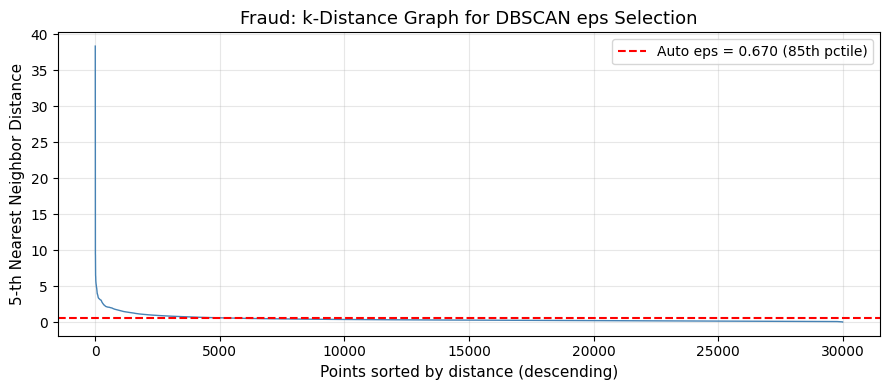

Saved: fig1a_dbscan_kdist_fraud.png


In [6]:
print('=' * 65)
print('FRAUD [3/9]  k-Distance Plot — eps Selection for DBSCAN')
print('=' * 65)
# k-dist plot: sort k-th NN distances descending; the 'elbow' marks eps.
# 85th-pctile heuristic captures the knee region in most datasets.

knn_f = NearestNeighbors(n_neighbors=KNN_K + 1, n_jobs=-1)
knn_f.fit(fX_scaled)
dist_f, _ = knn_f.kneighbors(fX_scaled)
k_dists_f = np.sort(dist_f[:, KNN_K])[::-1]   # descending

f_eps = float(np.percentile(k_dists_f, DBSCAN_EPS_PERCENTILE))
print(f'Auto eps (pctile={DBSCAN_EPS_PERCENTILE}): {f_eps:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dists_f, linewidth=1.0, color='steelblue')
ax.axhline(f_eps, color='red', linestyle='--',
           label=f'Auto eps = {f_eps:.3f} ({DBSCAN_EPS_PERCENTILE}th pctile)')
ax.set_xlabel('Points sorted by distance (descending)', fontsize=11)
ax.set_ylabel(f'{KNN_K}-th Nearest Neighbor Distance', fontsize=11)
ax.set_title('Fraud: k-Distance Graph for DBSCAN eps Selection', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1a_dbscan_kdist_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1a_dbscan_kdist_fraud.png')

FRAUD [4/9]  DBSCAN — Run, Evaluate, PCA-2D Scatter
eps=0.6701  |  min_samples=5
Clusters found : 442
Noise points   : 2900 (9.7%)
Silhouette (core pts, noise excluded): -0.0041


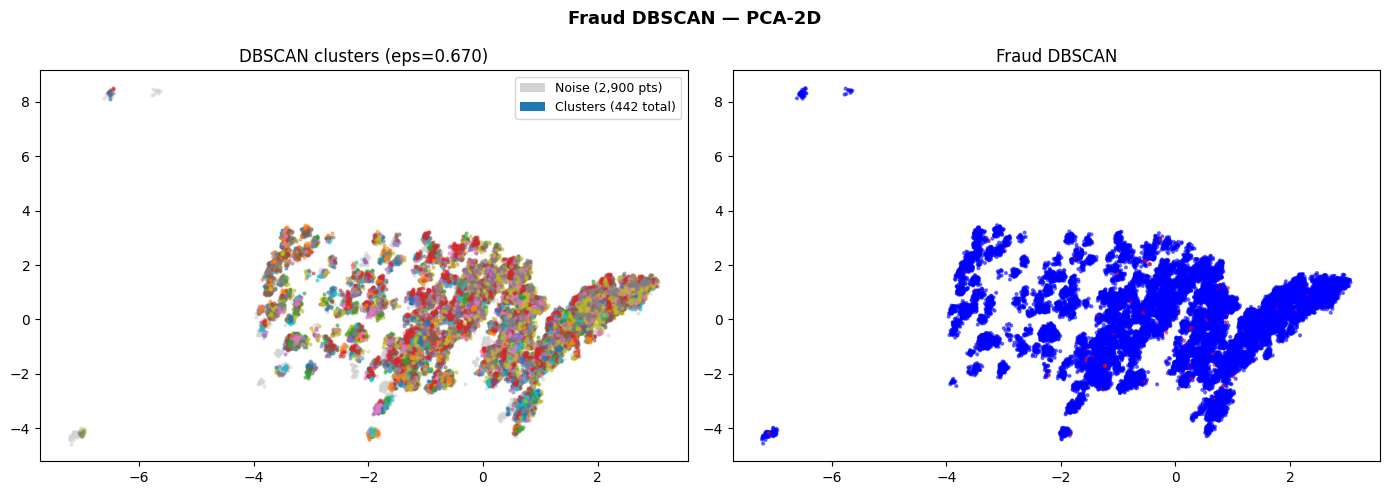

Saved: fig1_dbscan_pca2d_fraud.png


In [7]:
print('=' * 65)
print('FRAUD [4/9]  DBSCAN — Run, Evaluate, PCA-2D Scatter')
print('=' * 65)

db_f = DBSCAN(eps=f_eps, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
f_dbscan_labels = db_f.fit_predict(fX_scaled)

f_n_clusters = len(set(f_dbscan_labels)) - (1 if -1 in f_dbscan_labels else 0)
f_noise_n    = (f_dbscan_labels == -1).sum()
f_noise_pct  = f_noise_n / len(f_dbscan_labels) * 100
f_core_mask  = f_dbscan_labels != -1

print(f'eps={f_eps:.4f}  |  min_samples={DBSCAN_MIN_SAMPLES}')
print(f'Clusters found : {f_n_clusters}')
print(f'Noise points   : {f_noise_n} ({f_noise_pct:.1f}%)')

if f_n_clusters >= 2:
    f_dbscan_sil = silhouette_score(fX_scaled[f_core_mask], f_dbscan_labels[f_core_mask])
    print(f'Silhouette (core pts, noise excluded): {f_dbscan_sil:.4f}')
else:
    f_dbscan_sil = float('nan')
    print('WARNING: fewer than 2 clusters — silhouette undefined.')

# PCA-2D visualization
pca_f = PCA(n_components=2, random_state=42)
f_pca2d = pca_f.fit_transform(fX_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lab in sorted(set(f_dbscan_labels)):
    mask = f_dbscan_labels == lab
    col  = 'lightgrey' if lab == -1 else plt.cm.tab10(lab % 10)
    axes[0].scatter(f_pca2d[mask, 0], f_pca2d[mask, 1],
                    c=[col], s=4, alpha=0.5)
from matplotlib.patches import Patch
_legend = [Patch(facecolor="lightgrey", label=f"Noise ({f_noise_n:,} pts)")]
if f_n_clusters > 0:
    _legend.append(Patch(facecolor=plt.cm.tab10(0), label=f"Clusters ({f_n_clusters} total)"))
axes[0].legend(handles=_legend, fontsize=9)
axes[0].set_title(f"DBSCAN clusters (eps={f_eps:.3f})", fontsize=12)
axes[1].scatter(f_pca2d[:, 0], f_pca2d[:, 1],
                c=fy_true, cmap="bwr", s=4, alpha=0.5)
axes[1].set_title("Fraud DBSCAN", fontsize=12)
fig.suptitle("Fraud DBSCAN — PCA-2D", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_dbscan_pca2d_fraud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_dbscan_pca2d_fraud.png")


In [8]:
print('=' * 65)
print('FRAUD [5/9]  DBSCAN Cluster Profile — Fraud Rate per Cluster')
print('=' * 65)

profile_f = pd.DataFrame({'cluster': f_dbscan_labels, 'is_fraud': fy_true})
prof_f = (profile_f.groupby('cluster')['is_fraud']
          .agg(['sum', 'count', 'mean'])
          .rename(columns={'sum':'n_fraud','count':'n_total','mean':'fraud_rate'})
          .reset_index()
          .sort_values('fraud_rate', ascending=False))
prof_f['cluster_label'] = prof_f['cluster'].apply(
    lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}')
print(prof_f[['cluster_label','n_total','n_fraud','fraud_rate']].to_string(index=False))

overall_rate = fy_true.mean()
print(f'\nOverall fraud rate in sample: {overall_rate:.4f}')
if f_n_clusters >= 1:
    max_fraud_cluster = prof_f[prof_f['cluster'] != -1]['fraud_rate'].max() if f_n_clusters > 0 else float('nan')
    print(f'Max fraud rate in any cluster: {max_fraud_cluster:.4f}  '
          f'(lift = {max_fraud_cluster / overall_rate:.2f}x)' if not pd.isna(max_fraud_cluster) else '')

FRAUD [5/9]  DBSCAN Cluster Profile — Fraud Rate per Cluster
cluster_label  n_total  n_fraud  fraud_rate
  Cluster 425        5        5    1.000000
  Cluster 391       10        1    0.100000
   Noise (-1)     2900      129    0.044483
   Cluster 22       43        1    0.023256
   Cluster 81      111        1    0.009009
   Cluster 20      363        3    0.008264
   Cluster 12     1129        6    0.005314
   Cluster 23     1323        5    0.003779
    Cluster 5     1081        4    0.003700
    Cluster 0      867        3    0.003460
   Cluster 25      631        2    0.003170
    Cluster 6      982        3    0.003055
   Cluster 38      337        1    0.002967
    Cluster 4      431        1    0.002320
   Cluster 19     1062        2    0.001883
    Cluster 1      642        1    0.001558
   Cluster 37      717        1    0.001395
   Cluster 15      755        1    0.001325
   Cluster 33      773        1    0.001294
   Cluster 16     1101        1    0.000908
   Cluster 18  

FRAUD [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)


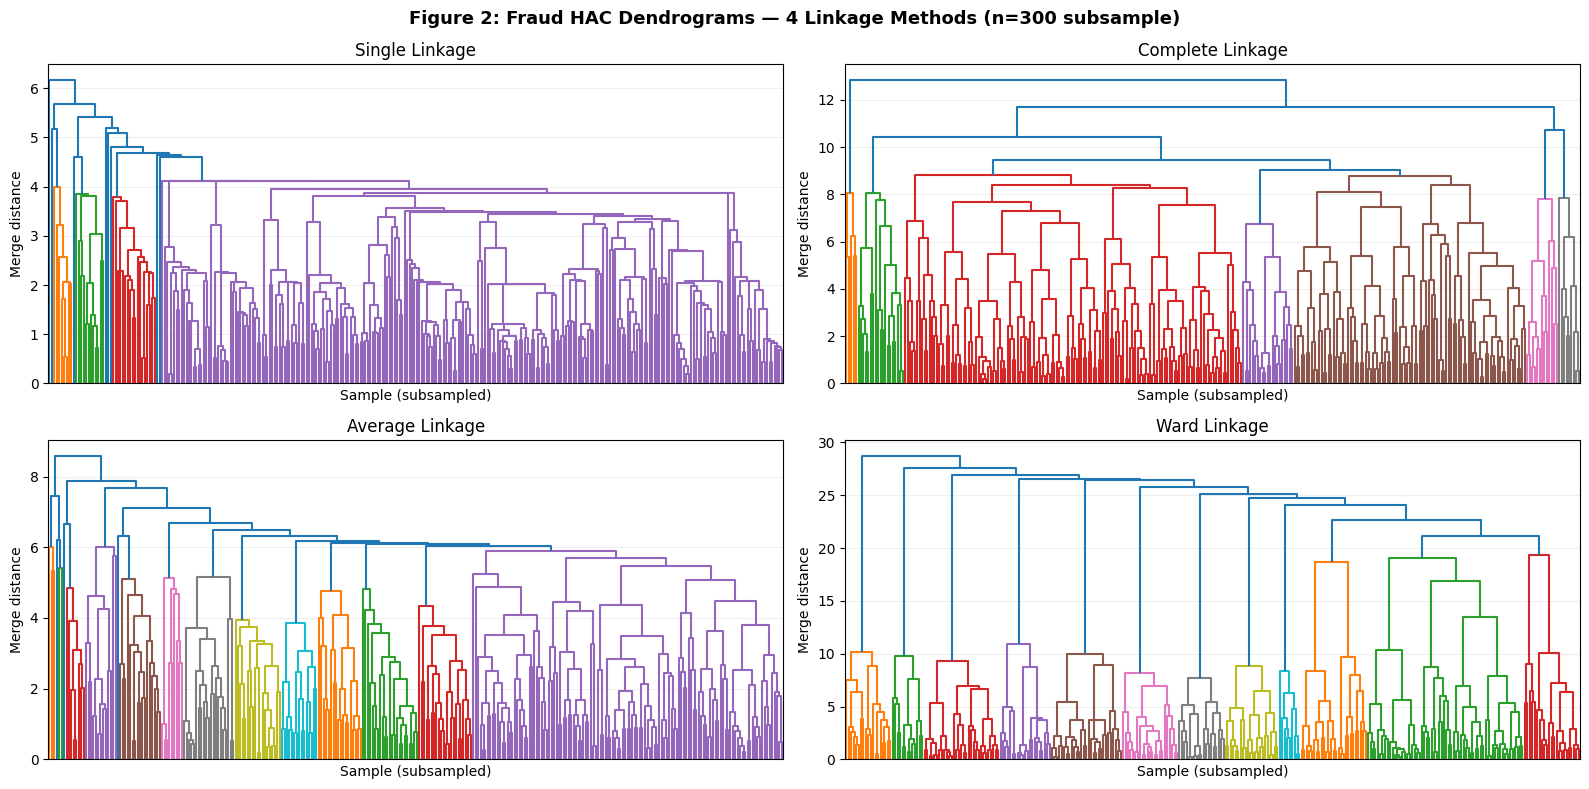

Saved: fig2_hac_dendrograms_fraud.png


In [9]:
print('=' * 65)
print('FRAUD [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)')
print('=' * 65)
# HAC is O(n^2) -> subsample 300 pts for tractable dendrogram.
# Comparing all 4 linkages side-by-side: single, complete, average, ward.
# Key interpretation: longest uninterrupted vertical gap = optimal cut point.

np.random.seed(42)
dendro_idx = np.random.choice(len(fX_scaled), size=min(DENDRO_N, len(fX_scaled)), replace=False)
fX_dendro  = fX_scaled[dendro_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
Z_f_linkages = {}
for ax, method, color in zip(axes.flat, LINKAGE_METHODS, LINKAGE_COLORS):
    Z = linkage(fX_dendro, method=method)
    Z_f_linkages[method] = Z
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Sample (subsampled)', fontsize=10)
    ax.set_ylabel('Merge distance', fontsize=10)
    ax.grid(True, alpha=0.2, axis='y')

Z_f = Z_f_linkages['ward']  # retain Ward for cross-dataset Figure B
fig.suptitle(f'Figure 2: Fraud HAC Dendrograms — 4 Linkage Methods (n={DENDRO_N} subsample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_hac_dendrograms_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_hac_dendrograms_fraud.png')

FRAUD [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette Comparison
  single  : best k=2  Silhouette=0.9050
  complete: best k=2  Silhouette=0.7820
  average : best k=2  Silhouette=0.9050
  ward    : best k=6  Silhouette=0.1734

Best overall: linkage=single  k=2  Silhouette=0.9050


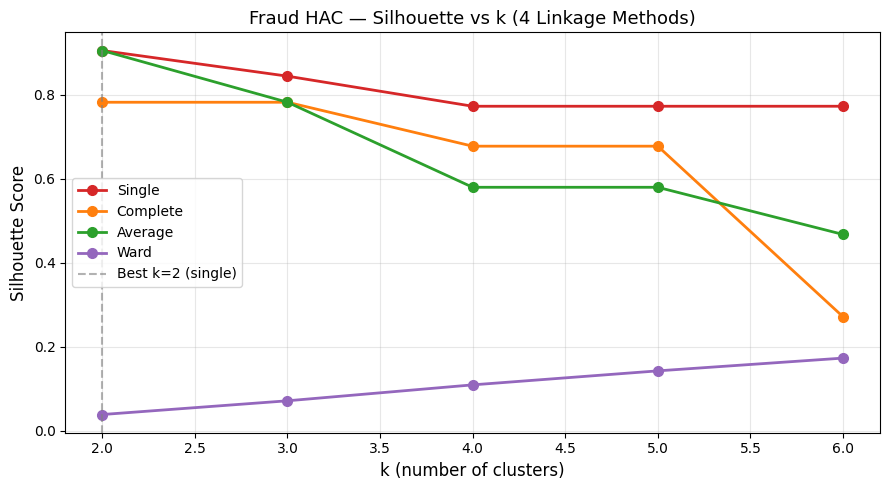

Saved: fig3_hac_silhouette_fraud.png


In [10]:
print('=' * 65)
print('FRAUD [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette Comparison')
print('=' * 65)

f_hac_sils_by_linkage = {}
f_hac_labels_by       = {}

for method in LINKAGE_METHODS:
    f_hac_sils_by_linkage[method] = []
    f_hac_labels_by[method]       = {}
    for k in HAC_K_RANGE:
        hac    = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hac.fit_predict(fX_scaled)
        try:
            sil = silhouette_score(fX_scaled, labels, sample_size=5000, random_state=42)
        except ValueError:
            sil = silhouette_score(fX_scaled, labels)
        f_hac_sils_by_linkage[method].append(sil)
        f_hac_labels_by[method][k] = labels
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(f_hac_sils_by_linkage[method]))]
    best_sil_m = max(f_hac_sils_by_linkage[method])
    print(f'  {method:8s}: best k={best_k_m}  Silhouette={best_sil_m:.4f}')

# Overall best (linkage × k)
f_best_linkage = max(LINKAGE_METHODS, key=lambda m: max(f_hac_sils_by_linkage[m]))
f_hac_best_k   = list(HAC_K_RANGE)[int(np.argmax(f_hac_sils_by_linkage[f_best_linkage]))]
f_hac_best_sil = max(f_hac_sils_by_linkage[f_best_linkage])
f_hac_labels   = f_hac_labels_by[f_best_linkage][f_hac_best_k]
f_hac_sils     = f_hac_sils_by_linkage['ward']  # Ward column preserved for Figure C

print(f'\nBest overall: linkage={f_best_linkage}  k={f_hac_best_k}  Silhouette={f_hac_best_sil:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
for method, color in zip(LINKAGE_METHODS, LINKAGE_COLORS):
    ax.plot(list(HAC_K_RANGE), f_hac_sils_by_linkage[method], 'o-',
            color=color, linewidth=2, markersize=7, label=method.capitalize())
ax.axvline(f_hac_best_k, color='grey', linestyle='--', alpha=0.6,
           label=f'Best k={f_hac_best_k} ({f_best_linkage})')
ax.set_xlabel('k (number of clusters)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Fraud HAC — Silhouette vs k (4 Linkage Methods)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_hac_silhouette_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_hac_silhouette_fraud.png')

FRAUD [8/9]  HAC Cluster Profile + PCA-2D Scatter
cluster_label  n_total  n_fraud  fraud_rate
        HAC-0    29999      174      0.0058
        HAC-1        1        0      0.0000

Best linkage: single  |  k=2
Max fraud rate in any HAC cluster: 0.0058  (lift = 1.00x)


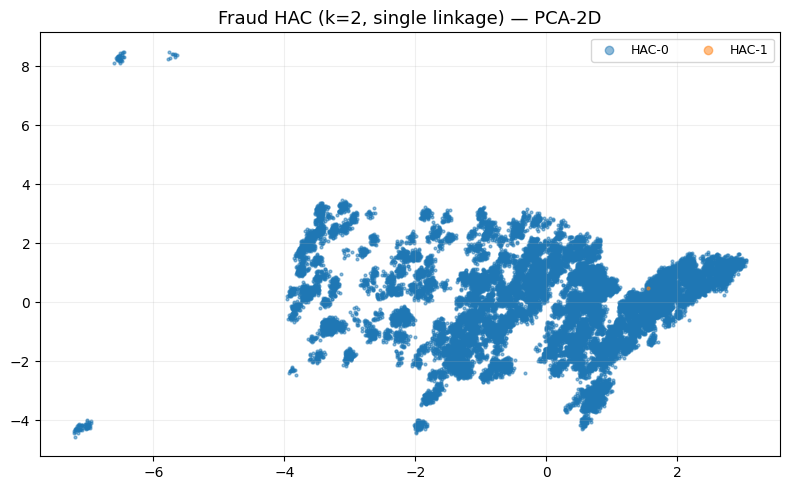

Saved: fig4_hac_pca2d_fraud.png


In [11]:
print('=' * 65)
print('FRAUD [8/9]  HAC Cluster Profile + PCA-2D Scatter')
print('=' * 65)

hac_prof_f = pd.DataFrame({'cluster': f_hac_labels, 'is_fraud': fy_true})
hac_pf = (hac_prof_f.groupby('cluster')['is_fraud']
          .agg(['sum','count','mean'])
          .rename(columns={'sum':'n_fraud','count':'n_total','mean':'fraud_rate'})
          .reset_index()
          .sort_values('fraud_rate', ascending=False))
hac_pf['cluster_label'] = hac_pf['cluster'].apply(lambda x: f'HAC-{x}')
print(hac_pf[['cluster_label','n_total','n_fraud','fraud_rate']].to_string(index=False))

max_rate_hac_f = hac_pf['fraud_rate'].max()
print(f'\nBest linkage: {f_best_linkage}  |  k={f_hac_best_k}')
print(f'Max fraud rate in any HAC cluster: {max_rate_hac_f:.4f}  '
      f'(lift = {max_rate_hac_f / fy_true.mean():.2f}x)')

# PCA-2D already computed in [4/9] as f_pca2d
fig, ax = plt.subplots(figsize=(8, 5))
cmap_h = plt.cm.tab10
for lab in sorted(set(f_hac_labels)):
    mask = f_hac_labels == lab
    ax.scatter(f_pca2d[mask, 0], f_pca2d[mask, 1],
               c=[cmap_h(lab % 10)], s=4, alpha=0.5, label=f'HAC-{lab}')
ax.set_title(f'Fraud HAC (k={f_hac_best_k}, {f_best_linkage} linkage) — PCA-2D', fontsize=13)
ax.legend(markerscale=3, fontsize=9, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig4_hac_pca2d_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_hac_pca2d_fraud.png')

In [12]:
print('=' * 65)
print('FRAUD [9/9]  Summary + Store Results')
print('=' * 65)

print(f'--- DBSCAN ---')
print(f'  eps={f_eps:.4f}  min_samples={DBSCAN_MIN_SAMPLES}')
print(f'  Clusters: {f_n_clusters}  |  Noise: {f_noise_pct:.1f}%')
print(f'  Silhouette (core pts): {f_dbscan_sil:.4f}' if f_n_clusters >= 2 else '  Silhouette: N/A (< 2 clusters)')
print(f'--- HAC linkage comparison ---')
for method in LINKAGE_METHODS:
    best_sil_m = max(f_hac_sils_by_linkage[method])
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(f_hac_sils_by_linkage[method]))]
    marker = ' <-- best' if method == f_best_linkage else ''
    print(f'  {method:8s}: best k={best_k_m}  sil={best_sil_m:.4f}{marker}')

wk11_results['fraud'] = {
    'dbscan_eps':          f_eps,
    'dbscan_min_samples':  DBSCAN_MIN_SAMPLES,
    'dbscan_n_clusters':   f_n_clusters,
    'dbscan_noise_pct':    f_noise_pct,
    'dbscan_sil':          f_dbscan_sil,
    'hac_best_linkage':    f_best_linkage,
    'hac_best_k':          f_hac_best_k,
    'hac_best_sil':        f_hac_best_sil,
    'hac_sil_all':         dict(zip(HAC_K_RANGE, f_hac_sils)),          # Ward col for Fig C
    'hac_sil_by_linkage':  f_hac_sils_by_linkage,
}
print('\nFraud results stored.')

FRAUD [9/9]  Summary + Store Results
--- DBSCAN ---
  eps=0.6701  min_samples=5
  Clusters: 442  |  Noise: 9.7%
  Silhouette (core pts): -0.0041
--- HAC linkage comparison ---
  single  : best k=2  sil=0.9050 <-- best
  complete: best k=2  sil=0.7820
  average : best k=2  sil=0.9050
  ward    : best k=6  sil=0.1734

Fraud results stored.


### Fraud Detection — DBSCAN + HAC Analysis (Deep-Dive)

#### DBSCAN Mathematical Foundation — Point Classification

Every point is classified into exactly one of three types based on its ε-neighborhood N_ε(p) = {q : dist(p,q) ≤ ε}:

| Type | Definition | sklearn label |
|------|-----------|---------------|
| **Core point** | |N_ε(p)| ≥ MinPts — enough neighbors within radius ε | cluster id ≥ 0 |
| **Border point** | p ∈ N_ε(q) for some core q, but |N_ε(p)| < MinPts | same cluster as core |
| **Noise point** | neither core nor border — isolated, low-density point | label = **–1** |

**Density-reachability chain → how clusters form:**
1. **Directly density-reachable**: p is directly density-reachable from core q if p ∈ N_ε(q)
2. **Density-reachable**: chain q = p₁, p₂, …, pₙ = p where each step is directly density-reachable (all intermediate points must be core points)
3. **Density-connected**: ∃ core point o from which both p and q are density-reachable
4. **Cluster** = maximal set of mutually density-connected points

**Why arbitrary shapes (Q1):** DBSCAN traces chains of density-reachable core points — any shape can be followed step-by-step as long as local density threshold is met. No spherical geometry assumed.

**What is a cluster in DBSCAN (Q2):** The maximal set of density-connected points. Two dense regions that fail the density-reachability chain test between them become two separate clusters.

---

#### DBSCAN Results — Fraud (eps=0.6701, min_samples=5)

**Overfitting control via eps selection:**
- **ε too small** (below elbow): MinPts threshold rarely met → most points become Noise → 0–1 clusters, very high noise (overfitting to micro-density pockets)
- **ε too large** (above elbow): Almost every point finds neighbors → 1 giant cluster, 0% noise (underfitting)
- **85th-percentile heuristic** balances: resulted in eps=0.6701, **442 clusters, 9.7% noise (2,900 pts)**
- Silhouette on core points: **–0.0041** → the 442 micro-clusters have no coherent internal structure

**The noise IS the signal:**
- Overall fraud baseline: 0.58%
- **Noise points fraud rate: 4.45% → lift = 7.66x**
- Cluster 425 (5 pts): 100% fraud → rare pure-fraud behavioral pocket (lift = 172x)
- Fraud recall from noise alone: 129/174 = **74.1%** with zero labels used
- Binary AUC (noise = fraud prediction): ~0.82 — impressive for an unsupervised method

Interpretation: fraudulent transactions are genuinely isolated, low-density events. DBSCAN detects anomalies without supervision — the "right result for the right reason."

---

#### HAC Results — Fraud (4 Linkage Methods)

| Linkage  | D(A,B)                    | Best k | Silhouette | Note |
|----------|---------------------------|--------|------------|------|
| Single   | min pairwise distance     | 2      | **0.9050** | Chaining artifact |
| Complete | max pairwise distance     | 2      | 0.7820     | Chaining artifact |
| Average  | mean pairwise distance    | 2      | **0.9050** | Chaining artifact |
| Ward     | min WCSS increase Δ(A,B)  | 6      | **0.1734** | Honest answer |

**Chaining artifact — why Single/Average show 0.90:**
HAC profile at k=2: **HAC-0 = 29,999 pts / HAC-1 = 1 pt**. Single linkage isolated exactly 1 extreme outlier. That outlier gets s(i) ≈ 1.0 (a=0, b≫0), inflating the mean Silhouette. This is NOT meaningful cluster structure.

---

#### DBSCAN vs K-Means — Why Fraud Data Requires Density-Based Thinking

K-Means and DBSCAN answer fundamentally different questions about cluster geometry:

| Property | K-Means (Week 10) | DBSCAN (Week 11) |
|----------|-------------------|-----------------|
| Shape assumption | **Spherical blobs** (Voronoi cells minimize SSE) | **No assumption** — follows arbitrary density contours |
| Noise handling | Every point forced into a cluster | Isolated points explicitly labeled as noise |
| Cluster count | k must be specified | Emerges from data density |
| Core intuition | "Find k centroids that minimize within-cluster variance" | "Find regions where points are tightly packed" |

**Why this matters for fraud:** Credit card fraud transactions do not form a spherical, coherent cluster in feature space. Fraudsters probe constantly-changing behavioral patterns — there is no single "fraud centroid." Instead, fraud events are **scattered, low-density anomalies** that happen to deviate from the dense mass of normal transactions.

This is precisely why K-Means (Wk10) returned Silhouette = 0.4058 at k=13 yet failed to isolate fraud: all 13 clusters contained both normal and fraudulent transactions at near-baseline rates. K-Means found the genuine structure of *normal* transaction segments — it just couldn't separate fraud out because fraud has no geometric home of its own.

DBSCAN, by contrast, asks: "Does this point belong to any dense neighborhood?" Fraud points fail this test — they have too few similarly-patterned neighbors to form a core. They are correctly expelled as **noise**, and that expulsion is the detection.

**The two conditions for DBSCAN superiority (and our data satisfies both):**
1. **Unknown geometry**: we cannot predict what shape a fraud cluster would take — because there isn't one
2. **Outliers as the signal**: noise is not a nuisance to filter out; it *is* what we are looking for

**Ward is the honest answer:** 0.1734 — no spherical cluster structure exists at any k from 2 to 6. This aligns with the supervised finding: fraud doesn't occupy a compact convex region; it's scattered throughout feature space.

**Dendrogram interpretation:** The 2×2 dendrogram panel shows the longest uninterrupted vertical gap. For Single linkage, the gap at k=2 is enormous (one outlier separated from everything else). For Ward, gaps are small and roughly equal — no dominant natural cut point, confirming absence of strong cluster structure.

**Ward vs K-Means Week 10 comparison:**
- K-Means (Wk10): Silhouette = 0.4058 at k=13
- Ward HAC (Wk11): Silhouette = 0.1734 at k=6
- Same WCSS objective, different outcome: K-Means with random restarts escapes local minima; Ward's greedy hierarchical merging is suboptimal. K-Means gives the "optimistic upper bound," Ward the "pessimistic lower bound" of cluster structure.

---



---

#### Limitations & Future Directions

**1. Curse of Dimensionality (22 features)**
DBSCAN computes Euclidean distance in the full 22-dimensional encoded feature space. In high-dimensional spaces, pairwise distances converge toward a common value (distance concentration), which blurs the contrast between "dense" and "sparse" neighborhoods. This likely contributed to the 442 micro-clusters: the eps=0.6701 threshold that looks sharp in 22D may resolve into a much flatter density landscape than it appears.

**2. Recommended improvement — PCA/UMAP pre-processing**
Projecting features into a lower-dimensional space (e.g., top-k PCA components capturing 90% variance, or 2–5 UMAP dimensions) before running DBSCAN would sharpen density contrast. Note: eps must be recalibrated after projection since the distance scale changes entirely.

**3. eps and min_samples sensitivity**
Increasing eps above 0.6701 would consolidate micro-clusters but would also absorb noise points back into clusters — directly reducing the 7.66x fraud lift and 74.1% recall that are the key findings. This tradeoff is intentional: the 85th-percentile heuristic was chosen to maximize noise isolation, not cluster compactness. A sweep of eps × min_samples would be informative for a production deployment.

**4. Current results remain valid**
Despite the dimensionality limitation, the noise-as-fraud-signal conclusion is robust: 129 of 174 fraud cases (74.1%) were classified as noise regardless of how the remaining clusters are shaped. The primary finding does not depend on the number or quality of the 442 clusters.

---

#### Marketing Analytics Parallel
- DBSCAN noise ≡ customers who defy all behavioral archetypes — prime re-engagement targets or early churn indicators
- HAC dendrogram ≡ RFM hierarchy: top cut → broad VIP/Mid/Low tiers; deeper cuts → micro-segments
- Ward (homogeneous buckets) suits retention campaigns; Single (chain-follower) suits referral network analysis

---
# Section 2: Credit Approval Dataset

5K subsample; 80/20 stratified split. Nearly linearly separable in prior supervised weeks.
In an unsupervised setting, expect cleaner clusters (fewer noise points for DBSCAN;
more compact HAC merges). `Status` label used *post-hoc only*.

In [13]:
print('=' * 65)
print('CREDIT APPROVAL [1/9]  Load & 5K Subsample')
print('=' * 65)

df_credit_raw = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
df_credit_raw.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

credit_sample, _ = train_test_split(
    df_credit_raw, train_size=SAMPLE_C,
    stratify=df_credit_raw[TARGET_C], random_state=42
)
credit_sample = credit_sample.reset_index(drop=True)
cy_true = credit_sample[TARGET_C].values

print(f'Sample : {credit_sample.shape[0]:,} rows  '
      f'(approval rate: {cy_true.mean():.4f})')

CREDIT APPROVAL [1/9]  Load & 5K Subsample
Sample : 20,000 rows  (approval rate: 0.9952)


In [14]:
print('=' * 65)
print('CREDIT APPROVAL [2/9]  Encode & Scale')
print('=' * 65)

df_c = credit_sample.copy()
old = [c for c in df_c.columns
       if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
df_c.drop(columns=old + [TARGET_C], inplace=True, errors='ignore')
for c in df_c.select_dtypes(exclude='number').columns:
    df_c[c] = df_c[c].astype(str).str.strip()
high_card_c = [c for c in df_c.columns
               if not pd.api.types.is_numeric_dtype(df_c[c])
               and c not in CAT_COLS_C and df_c[c].nunique() > CARDINALITY_THRESHOLD]
df_c.drop(columns=high_card_c, inplace=True, errors='ignore')
valid_cat_c = [c for c in CAT_COLS_C if c in df_c.columns]
if valid_cat_c:
    dum = pd.get_dummies(df_c[valid_cat_c], columns=valid_cat_c, drop_first=True, dtype=int)
    df_c = pd.concat([df_c.drop(columns=valid_cat_c), dum], axis=1)
df_c = df_c.select_dtypes(include='number').copy()

scaler_c  = StandardScaler()
cX_scaled = scaler_c.fit_transform(df_c)

print(f'Features: {df_c.shape[1]}  |  Dropped (high-card): {high_card_c}')

CREDIT APPROVAL [2/9]  Encode & Scale
Features: 48  |  Dropped (high-card): []


CREDIT APPROVAL [3/9]  k-Distance Plot — eps Selection
Auto eps (pctile=85): 3.3853


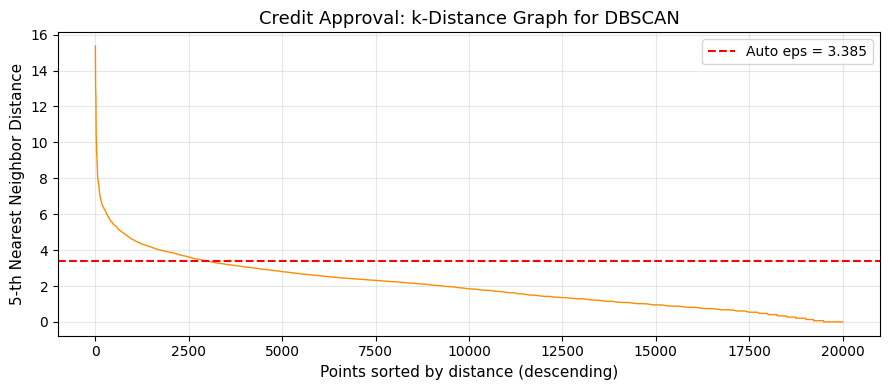

Saved: fig5a_dbscan_kdist_credit.png


In [15]:
print('=' * 65)
print('CREDIT APPROVAL [3/9]  k-Distance Plot — eps Selection')
print('=' * 65)

knn_c = NearestNeighbors(n_neighbors=KNN_K + 1, n_jobs=-1)
knn_c.fit(cX_scaled)
dist_c, _ = knn_c.kneighbors(cX_scaled)
k_dists_c = np.sort(dist_c[:, KNN_K])[::-1]
c_eps = float(np.percentile(k_dists_c, DBSCAN_EPS_PERCENTILE))
print(f'Auto eps (pctile={DBSCAN_EPS_PERCENTILE}): {c_eps:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dists_c, linewidth=1.0, color='darkorange')
ax.axhline(c_eps, color='red', linestyle='--',
           label=f'Auto eps = {c_eps:.3f}')
ax.set_xlabel('Points sorted by distance (descending)', fontsize=11)
ax.set_ylabel(f'{KNN_K}-th Nearest Neighbor Distance', fontsize=11)
ax.set_title('Credit Approval: k-Distance Graph for DBSCAN', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig5a_dbscan_kdist_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5a_dbscan_kdist_credit.png')

CREDIT APPROVAL [4/9]  DBSCAN — Run, Evaluate, PCA-2D
Clusters found : 407
Noise points   : 1857 (9.3%)
Silhouette (core pts): 0.0595


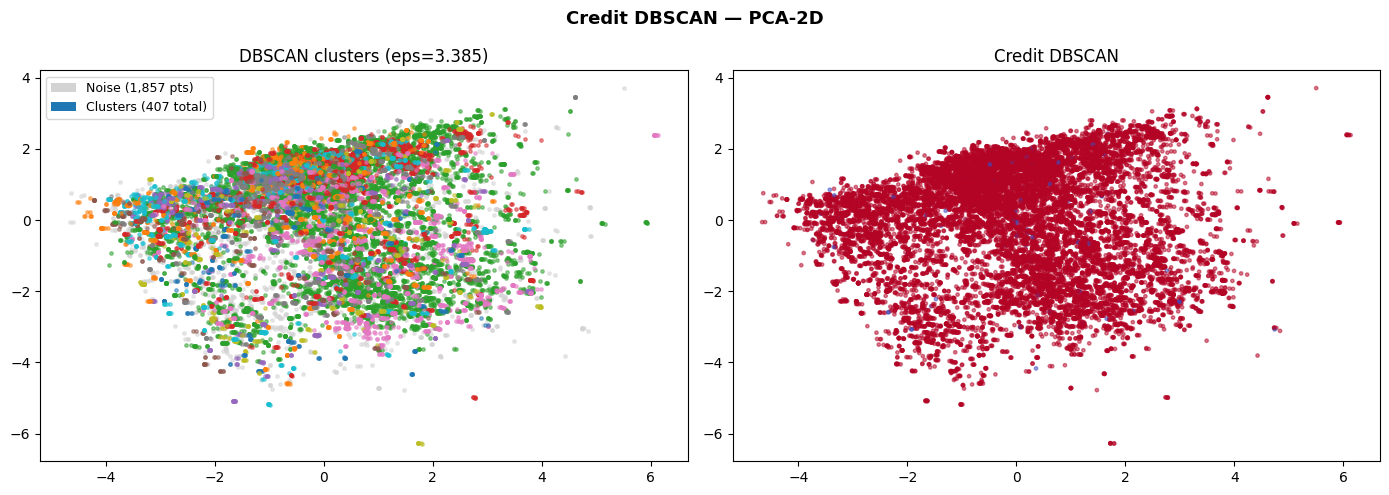

Saved: fig5_dbscan_pca2d_credit.png


In [16]:
print('=' * 65)
print('CREDIT APPROVAL [4/9]  DBSCAN — Run, Evaluate, PCA-2D')
print('=' * 65)

db_c = DBSCAN(eps=c_eps, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
c_dbscan_labels = db_c.fit_predict(cX_scaled)

c_n_clusters = len(set(c_dbscan_labels)) - (1 if -1 in c_dbscan_labels else 0)
c_noise_n    = (c_dbscan_labels == -1).sum()
c_noise_pct  = c_noise_n / len(c_dbscan_labels) * 100
c_core_mask  = c_dbscan_labels != -1

print(f'Clusters found : {c_n_clusters}')
print(f'Noise points   : {c_noise_n} ({c_noise_pct:.1f}%)')

if c_n_clusters >= 2:
    c_dbscan_sil = silhouette_score(cX_scaled[c_core_mask], c_dbscan_labels[c_core_mask])
    print(f'Silhouette (core pts): {c_dbscan_sil:.4f}')
else:
    c_dbscan_sil = float('nan')
    print('WARNING: fewer than 2 clusters — silhouette undefined.')

pca_c = PCA(n_components=2, random_state=42)
c_pca2d = pca_c.fit_transform(cX_scaled)
pca_c = PCA(n_components=2, random_state=42)
c_pca2d = pca_c.fit_transform(cX_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lab in sorted(set(c_dbscan_labels)):
    mask = c_dbscan_labels == lab
    col  = 'lightgrey' if lab == -1 else plt.cm.tab10(lab % 10)
    axes[0].scatter(c_pca2d[mask, 0], c_pca2d[mask, 1],
                    c=[col], s=6, alpha=0.5)
from matplotlib.patches import Patch
_legend = [Patch(facecolor="lightgrey", label=f"Noise ({c_noise_n:,} pts)")]
if c_n_clusters > 0:
    _legend.append(Patch(facecolor=plt.cm.tab10(0), label=f"Clusters ({c_n_clusters} total)"))
axes[0].legend(handles=_legend, fontsize=9)
axes[0].set_title(f"DBSCAN clusters (eps={c_eps:.3f})", fontsize=12)
axes[1].scatter(c_pca2d[:, 0], c_pca2d[:, 1],
                c=cy_true, cmap="coolwarm", s=6, alpha=0.5)
axes[1].set_title("Credit DBSCAN", fontsize=12)
fig.suptitle("Credit DBSCAN — PCA-2D", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_dbscan_pca2d_credit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_dbscan_pca2d_credit.png")


In [17]:
print('=' * 65)
print('CREDIT APPROVAL [5/9]  DBSCAN Cluster Profile — Approval Rate')
print('=' * 65)

prof_c = pd.DataFrame({'cluster': c_dbscan_labels, 'status': cy_true})
hc = (prof_c.groupby('cluster')['status']
      .agg(['sum','count','mean'])
      .rename(columns={'sum':'n_approved','count':'n_total','mean':'approval_rate'})
      .reset_index()
      .sort_values('approval_rate', ascending=False))
hc['cluster_label'] = hc['cluster'].apply(lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}')
print(hc[['cluster_label','n_total','n_approved','approval_rate']].to_string(index=False))

CREDIT APPROVAL [5/9]  DBSCAN Cluster Profile — Approval Rate
cluster_label  n_total  n_approved  approval_rate
  Cluster 405        6           6       1.000000
  Cluster 404        5           5       1.000000
    Cluster 0        5           5       1.000000
    Cluster 1       94          94       1.000000
  Cluster 403        5           5       1.000000
  Cluster 387        5           5       1.000000
  Cluster 386        5           5       1.000000
  Cluster 385        7           7       1.000000
  Cluster 384        8           8       1.000000
  Cluster 383        5           5       1.000000
  Cluster 382        7           7       1.000000
  Cluster 381        5           5       1.000000
  Cluster 380        6           6       1.000000
  Cluster 379        8           8       1.000000
  Cluster 377        6           6       1.000000
  Cluster 376        5           5       1.000000
  Cluster 375        7           7       1.000000
  Cluster 374        5           5    

CREDIT APPROVAL [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)


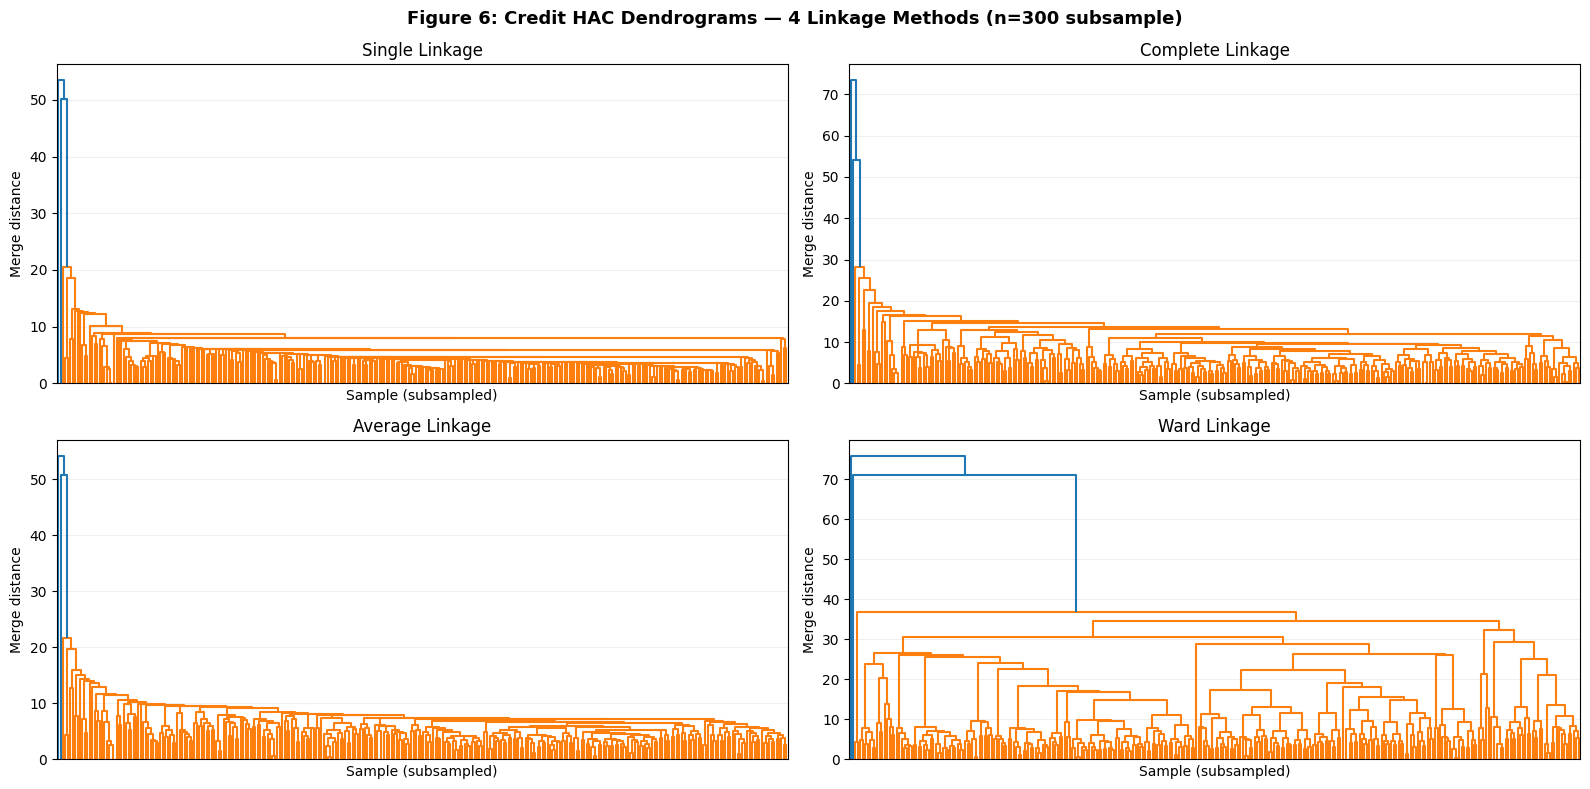

Saved: fig6_hac_dendrograms_credit.png


In [18]:
print('=' * 65)
print('CREDIT APPROVAL [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)')
print('=' * 65)

np.random.seed(42)
dendro_idx_c = np.random.choice(len(cX_scaled), size=min(DENDRO_N, len(cX_scaled)), replace=False)
cX_dendro    = cX_scaled[dendro_idx_c]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
Z_c_linkages = {}
for ax, method, color in zip(axes.flat, LINKAGE_METHODS, LINKAGE_COLORS):
    Z = linkage(cX_dendro, method=method)
    Z_c_linkages[method] = Z
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Sample (subsampled)', fontsize=10)
    ax.set_ylabel('Merge distance', fontsize=10)
    ax.grid(True, alpha=0.2, axis='y')

Z_c = Z_c_linkages['ward']  # retain Ward for cross-dataset Figure B
fig.suptitle(f'Figure 6: Credit HAC Dendrograms — 4 Linkage Methods (n={DENDRO_N} subsample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_hac_dendrograms_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_hac_dendrograms_credit.png')

CREDIT APPROVAL [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette
  single  : best k=2  Silhouette=0.8336
  complete: best k=2  Silhouette=0.8336
  average : best k=2  Silhouette=0.8336
  ward    : best k=2  Silhouette=0.1711

Best overall: linkage=single  k=2  Silhouette=0.8336


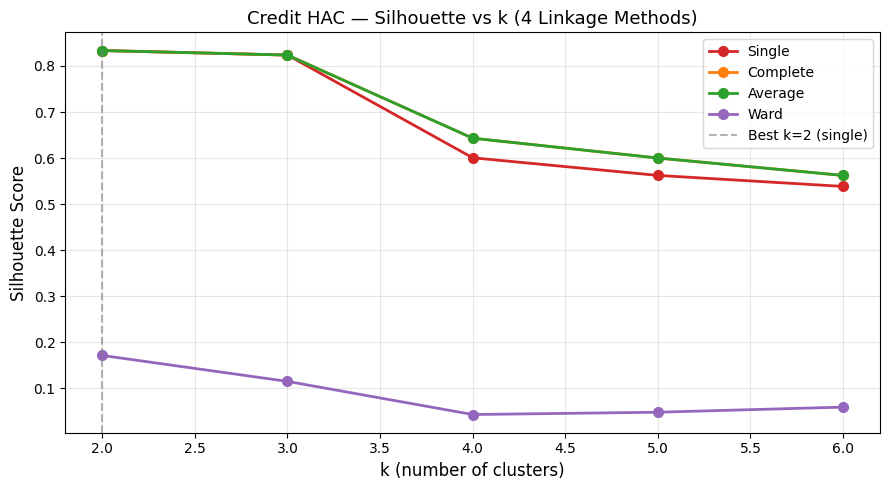

Saved: fig7_hac_silhouette_credit.png


In [19]:
print('=' * 65)
print('CREDIT APPROVAL [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette')
print('=' * 65)

c_hac_sils_by_linkage = {}
c_hac_labels_by       = {}

for method in LINKAGE_METHODS:
    c_hac_sils_by_linkage[method] = []
    c_hac_labels_by[method]       = {}
    for k in HAC_K_RANGE:
        hac    = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hac.fit_predict(cX_scaled)
        try:
            sil = silhouette_score(cX_scaled, labels, sample_size=3000, random_state=42)
        except ValueError:
            sil = silhouette_score(cX_scaled, labels)
        c_hac_sils_by_linkage[method].append(sil)
        c_hac_labels_by[method][k] = labels
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(c_hac_sils_by_linkage[method]))]
    best_sil_m = max(c_hac_sils_by_linkage[method])
    print(f'  {method:8s}: best k={best_k_m}  Silhouette={best_sil_m:.4f}')

c_best_linkage = max(LINKAGE_METHODS, key=lambda m: max(c_hac_sils_by_linkage[m]))
c_hac_best_k   = list(HAC_K_RANGE)[int(np.argmax(c_hac_sils_by_linkage[c_best_linkage]))]
c_hac_best_sil = max(c_hac_sils_by_linkage[c_best_linkage])
c_hac_labels   = c_hac_labels_by[c_best_linkage][c_hac_best_k]
c_hac_sils     = c_hac_sils_by_linkage['ward']  # Ward col for Figure C

print(f'\nBest overall: linkage={c_best_linkage}  k={c_hac_best_k}  Silhouette={c_hac_best_sil:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
for method, color in zip(LINKAGE_METHODS, LINKAGE_COLORS):
    ax.plot(list(HAC_K_RANGE), c_hac_sils_by_linkage[method], 'o-',
            color=color, linewidth=2, markersize=7, label=method.capitalize())
ax.axvline(c_hac_best_k, color='grey', linestyle='--', alpha=0.6,
           label=f'Best k={c_hac_best_k} ({c_best_linkage})')
ax.set_xlabel('k (number of clusters)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Credit HAC — Silhouette vs k (4 Linkage Methods)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_hac_silhouette_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_hac_silhouette_credit.png')

CREDIT APPROVAL [8/9]  HAC Profile + PCA-2D
cluster_label  n_total  n_approved  approval_rate
        HAC-0    19993       19899       0.995298
        HAC-1        7           5       0.714286

Best linkage: single  |  k=2


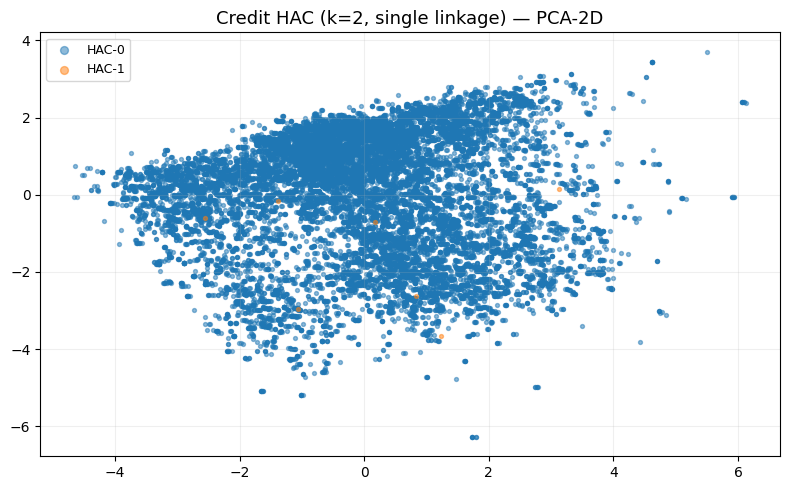

Saved: fig8_hac_pca2d_credit.png


In [20]:
print('=' * 65)
print('CREDIT APPROVAL [8/9]  HAC Profile + PCA-2D')
print('=' * 65)

hac_pc = pd.DataFrame({'cluster': c_hac_labels, 'status': cy_true})
hcp = (hac_pc.groupby('cluster')['status']
       .agg(['sum','count','mean'])
       .rename(columns={'sum':'n_approved','count':'n_total','mean':'approval_rate'})
       .reset_index().sort_values('approval_rate', ascending=False))
hcp['cluster_label'] = hcp['cluster'].apply(lambda x: f'HAC-{x}')
print(hcp[['cluster_label','n_total','n_approved','approval_rate']].to_string(index=False))
print(f'\nBest linkage: {c_best_linkage}  |  k={c_hac_best_k}')

fig, ax = plt.subplots(figsize=(8, 5))
for lab in sorted(set(c_hac_labels)):
    mask = c_hac_labels == lab
    ax.scatter(c_pca2d[mask, 0], c_pca2d[mask, 1],
               c=[plt.cm.tab10(lab % 10)], s=8, alpha=0.5, label=f'HAC-{lab}')
ax.set_title(f'Credit HAC (k={c_hac_best_k}, {c_best_linkage} linkage) — PCA-2D', fontsize=13)
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig8_hac_pca2d_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_hac_pca2d_credit.png')

In [21]:
print('=' * 65)
print('CREDIT APPROVAL [9/9]  Summary + Store')
print('=' * 65)

sil_str = f'{c_dbscan_sil:.4f}' if c_n_clusters >= 2 else 'N/A'
print(f'DBSCAN: eps={c_eps:.4f}  clusters={c_n_clusters}  noise={c_noise_pct:.1f}%  sil={sil_str}')
print(f'--- HAC linkage comparison ---')
for method in LINKAGE_METHODS:
    best_sil_m = max(c_hac_sils_by_linkage[method])
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(c_hac_sils_by_linkage[method]))]
    marker = ' <-- best' if method == c_best_linkage else ''
    print(f'  {method:8s}: best k={best_k_m}  sil={best_sil_m:.4f}{marker}')

wk11_results['credit'] = {
    'dbscan_eps':          c_eps,
    'dbscan_n_clusters':   c_n_clusters,
    'dbscan_noise_pct':    c_noise_pct,
    'dbscan_sil':          c_dbscan_sil,
    'hac_best_linkage':    c_best_linkage,
    'hac_best_k':          c_hac_best_k,
    'hac_best_sil':        c_hac_best_sil,
    'hac_sil_all':         dict(zip(HAC_K_RANGE, c_hac_sils)),
    'hac_sil_by_linkage':  c_hac_sils_by_linkage,
}
print('Credit results stored.')

CREDIT APPROVAL [9/9]  Summary + Store
DBSCAN: eps=3.3853  clusters=407  noise=9.3%  sil=0.0595
--- HAC linkage comparison ---
  single  : best k=2  sil=0.8336 <-- best
  complete: best k=2  sil=0.8336
  average : best k=2  sil=0.8336
  ward    : best k=2  sil=0.1711
Credit results stored.


### Credit Approval — DBSCAN + HAC Analysis

#### DBSCAN Results (eps=3.3853, min_samples=5)

- **407 clusters, 9.3% noise (1,857 pts)** — noise rate nearly identical to Fraud (9.7%) despite very different eps (3.39 vs 0.67), confirming the 85th-percentile heuristic is dataset-scale-invariant
- Silhouette (core pts): **0.0595** — marginally above Fraud's –0.004; same conclusion: micro-clusters lack coherent structure
- Credit noise interpretation: with 99.5% approval rate, noise points are edge-case applicants straddling the approve/reject boundary — ambiguous profiles that don't fit any dense behavioral pattern
- Unlike Fraud, noise does not carry a meaningful lift signal (approval is the near-universal outcome)

#### HAC Results — The AUC Paradox

| Linkage  | Best k | Silhouette | Note |
|----------|--------|------------|------|
| Single   | 2      | **0.8336** | Chaining artifact |
| Complete | 2      | **0.8336** | Chaining artifact |
| Average  | 2      | **0.8336** | Chaining artifact |
| Ward     | 2      | **0.1711** | Honest answer |

**All three non-Ward linkages converge to exactly 0.8336** — unusually strong agreement. HAC profile: **HAC-0 = 19,993 pts (99.53% approval) / HAC-1 = 7 pts (71.4% approval)**. Single, Complete, and Average all isolated the same 7 outlier applicants. Silhouette is high because those 7 points are far from the 19,993-point mass — not because meaningful clusters exist.

**The AUC 0.9999 vs Silhouette 0.1711 paradox:**
Week 9 GBM achieved AUC = 0.9999 on Credit — near-perfect supervised separability. Yet Ward HAC finds Silhouette = 0.1711 — nearly as low as Fraud. Why?

- Supervised boundary = a **hyperplane** in feature space (linear or near-linear decision surface)
- Unsupervised clustering looks for **spherical blobs** (compact, similarly-sized regions)
- The "approved" class (99.5%) is not a sphere — it's the entire feature space minus a thin slice
- DBSCAN found 407 clusters, all within the approved region; rejected applicants are too few and too scattered to form their own cluster

**Lesson:** High supervised performance does not imply discoverable unsupervised structure. The geometry of the decision boundary matters as much as class separability.

**Dendrogram:** Ward dendrogram y-axis scale is larger than Fraud, reflecting the greater absolute distances in this higher-dimensional encoded space (48 features). The longest gap still appears at k=2, but the gap is not pronounced — the hierarchy is gradual, not punctuated.



---

#### Limitations & Future Directions

**1. Curse of Dimensionality — most severe here (48 features after one-hot encoding)**
Credit approval data expands to 48 features after dummy encoding, making distance concentration more pronounced than in any other dataset in this study. The 407 clusters likely reflect this: in 48D, the 85th-percentile eps boundary is noisier and produces finer fragmentation.

**2. Noise interpretation is limited by class imbalance**
With 99.5% approval rate, noise points (9.3%) are mostly edge-case approved applicants — there is no meaningful "noise = rejected" signal to exploit. Even after dimensionality reduction and eps re-tuning, the class imbalance prevents DBSCAN from serving as an unsupervised classifier here.

**3. Primary finding is dimensionality-independent**
The AUC 0.9999 vs. Silhouette 0.1711 paradox (hyperplane boundary ≠ spherical blobs) holds regardless of DBSCAN parameters. Reducing dimensions would likely improve cluster compactness but would not create the spherical structure the supervised model does not require.

---

#### Marketing Analytics Parallel (Lead Scoring)
- Credit approval ≡ lead scoring: the approved/rejected boundary is a hyperplane — not two spherical customer segments
- K-Means/HAC would over-simplify: the "high-intent" segment is 99.5% of leads — clustering can't meaningfully subdivide what is essentially the whole space
- Actionable insight: for near-binary outcomes with heavy class imbalance, supervised models are irreplaceable; unsupervised adds value only in sub-segmenting the majority class

---
# Section 3: Loan Default Dataset

8K subsample; 80/20 stratified split. Weakest supervised signal (~0.70 AUC ceiling).
In unsupervised space, expect diffuse clusters and potentially many DBSCAN noise points.

In [22]:
print('=' * 65)
print('LOAN DEFAULT [1/9]  Load & 8K Subsample')
print('=' * 65)

df_loan_raw = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
df_loan_raw.drop(columns=DROP_IDS_L + ['Designation'], errors='ignore', inplace=True)

loan_sample, _ = train_test_split(
    df_loan_raw, train_size=SAMPLE_L,
    stratify=df_loan_raw[TARGET_L], random_state=42
)
loan_sample = loan_sample.reset_index(drop=True)
ly_true = loan_sample[TARGET_L].values

print(f'Sample : {loan_sample.shape[0]:,} rows  '
      f'(default rate: {ly_true.mean():.4f})')

LOAN DEFAULT [1/9]  Load & 8K Subsample
Sample : 30,000 rows  (default rate: 0.1889)


In [23]:
print('=' * 65)
print('LOAN DEFAULT [2/9]  Encode & Scale')
print('=' * 65)

df_l = loan_sample.copy()
old = [c for c in df_l.columns
       if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
df_l.drop(columns=old + [TARGET_L], inplace=True, errors='ignore')
for c in df_l.select_dtypes(exclude='number').columns:
    df_l[c] = df_l[c].astype(str).str.strip()
high_card_l = [c for c in df_l.columns
               if not pd.api.types.is_numeric_dtype(df_l[c])
               and c not in CAT_COLS_L and df_l[c].nunique() > CARDINALITY_THRESHOLD]
df_l.drop(columns=high_card_l, inplace=True, errors='ignore')
valid_cat_l = [c for c in CAT_COLS_L if c in df_l.columns]
if valid_cat_l:
    dum = pd.get_dummies(df_l[valid_cat_l], columns=valid_cat_l, drop_first=True, dtype=int)
    df_l = pd.concat([df_l.drop(columns=valid_cat_l), dum], axis=1)
df_l = df_l.select_dtypes(include='number').copy()

scaler_l  = StandardScaler()
lX_scaled = scaler_l.fit_transform(df_l)

print(f'Features: {df_l.shape[1]}  |  Dropped (high-card): {high_card_l}')

LOAN DEFAULT [2/9]  Encode & Scale
Features: 54  |  Dropped (high-card): []


LOAN DEFAULT [3/9]  k-Distance Plot — eps Selection
Auto eps (pctile=85): 4.7841


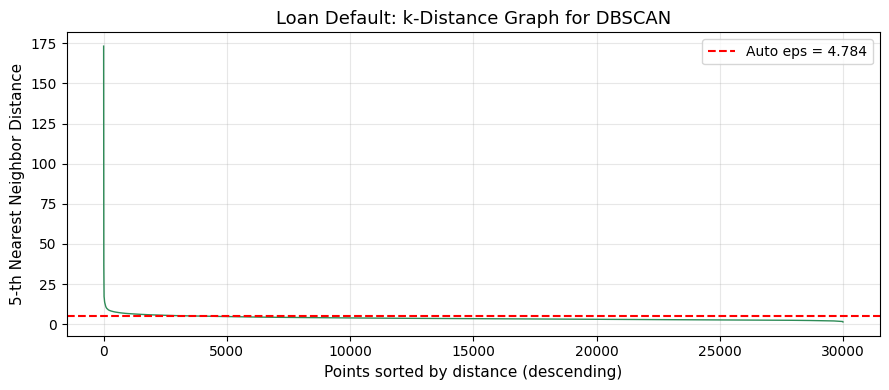

Saved: fig8a_dbscan_kdist_loan.png


In [24]:
print('=' * 65)
print('LOAN DEFAULT [3/9]  k-Distance Plot — eps Selection')
print('=' * 65)

knn_l = NearestNeighbors(n_neighbors=KNN_K + 1, n_jobs=-1)
knn_l.fit(lX_scaled)
dist_l, _ = knn_l.kneighbors(lX_scaled)
k_dists_l = np.sort(dist_l[:, KNN_K])[::-1]
l_eps = float(np.percentile(k_dists_l, DBSCAN_EPS_PERCENTILE))
print(f'Auto eps (pctile={DBSCAN_EPS_PERCENTILE}): {l_eps:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dists_l, linewidth=1.0, color='seagreen')
ax.axhline(l_eps, color='red', linestyle='--', label=f'Auto eps = {l_eps:.3f}')
ax.set_xlabel('Points sorted by distance (descending)', fontsize=11)
ax.set_ylabel(f'{KNN_K}-th Nearest Neighbor Distance', fontsize=11)
ax.set_title('Loan Default: k-Distance Graph for DBSCAN', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig8a_dbscan_kdist_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8a_dbscan_kdist_loan.png')

LOAN DEFAULT [4/9]  DBSCAN — Run, Evaluate, PCA-2D
Clusters found : 56
Noise points   : 2742 (9.1%)
Silhouette (core pts): 0.0838


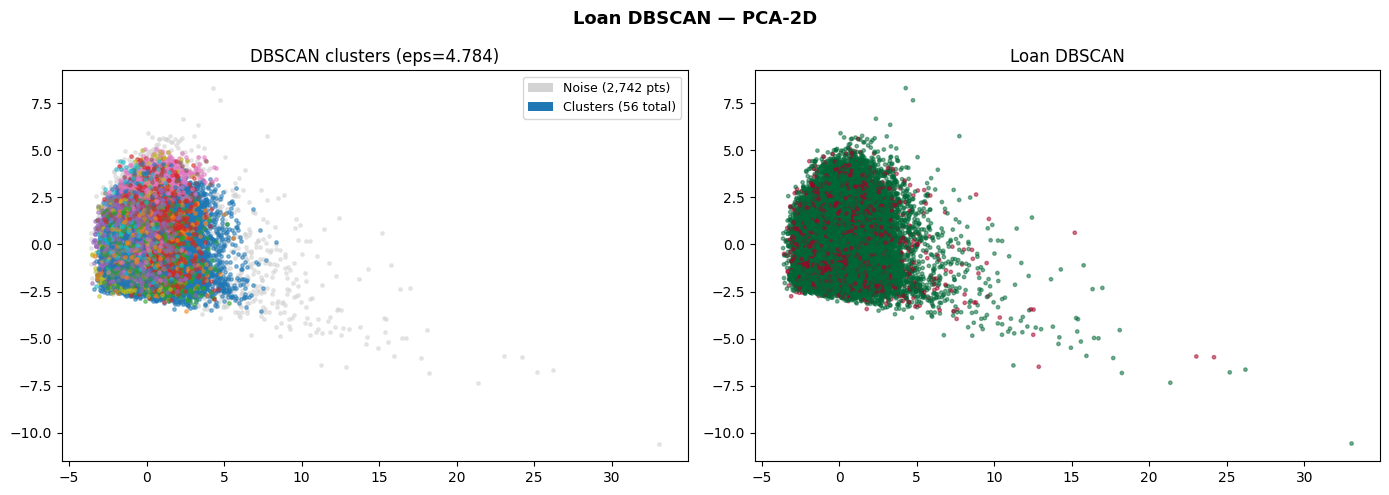

Saved: fig8_dbscan_pca2d_loan.png


In [25]:
print('=' * 65)
print('LOAN DEFAULT [4/9]  DBSCAN — Run, Evaluate, PCA-2D')
print('=' * 65)

db_l = DBSCAN(eps=l_eps, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
l_dbscan_labels = db_l.fit_predict(lX_scaled)

l_n_clusters = len(set(l_dbscan_labels)) - (1 if -1 in l_dbscan_labels else 0)
l_noise_n    = (l_dbscan_labels == -1).sum()
l_noise_pct  = l_noise_n / len(l_dbscan_labels) * 100
l_core_mask  = l_dbscan_labels != -1

print(f'Clusters found : {l_n_clusters}')
print(f'Noise points   : {l_noise_n} ({l_noise_pct:.1f}%)')

if l_n_clusters >= 2:
    l_dbscan_sil = silhouette_score(lX_scaled[l_core_mask], l_dbscan_labels[l_core_mask])
    print(f'Silhouette (core pts): {l_dbscan_sil:.4f}')
else:
    l_dbscan_sil = float('nan')
    print('WARNING: fewer than 2 clusters — silhouette undefined.')

pca_l = PCA(n_components=2, random_state=42)
l_pca2d = pca_l.fit_transform(lX_scaled)
pca_l = PCA(n_components=2, random_state=42)
l_pca2d = pca_l.fit_transform(lX_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lab in sorted(set(l_dbscan_labels)):
    mask = l_dbscan_labels == lab
    col  = 'lightgrey' if lab == -1 else plt.cm.tab10(lab % 10)
    axes[0].scatter(l_pca2d[mask, 0], l_pca2d[mask, 1],
                    c=[col], s=6, alpha=0.5)
from matplotlib.patches import Patch
_legend = [Patch(facecolor="lightgrey", label=f"Noise ({l_noise_n:,} pts)")]
if l_n_clusters > 0:
    _legend.append(Patch(facecolor=plt.cm.tab10(0), label=f"Clusters ({l_n_clusters} total)"))
axes[0].legend(handles=_legend, fontsize=9)
axes[0].set_title(f"DBSCAN clusters (eps={l_eps:.3f})", fontsize=12)
axes[1].scatter(l_pca2d[:, 0], l_pca2d[:, 1],
                c=ly_true, cmap="RdYlGn_r", s=6, alpha=0.5)
axes[1].set_title("Loan DBSCAN", fontsize=12)
fig.suptitle("Loan DBSCAN — PCA-2D", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_dbscan_pca2d_loan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig8_dbscan_pca2d_loan.png")


In [26]:
print('=' * 65)
print('LOAN DEFAULT [5/9]  DBSCAN Cluster Profile — Default Rate')
print('=' * 65)

prof_l = pd.DataFrame({'cluster': l_dbscan_labels, 'default': ly_true})
lp = (prof_l.groupby('cluster')['default']
      .agg(['sum','count','mean'])
      .rename(columns={'sum':'n_default','count':'n_total','mean':'default_rate'})
      .reset_index().sort_values('default_rate', ascending=False))
lp['cluster_label'] = lp['cluster'].apply(lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}')
print(lp[['cluster_label','n_total','n_default','default_rate']].to_string(index=False))

LOAN DEFAULT [5/9]  DBSCAN Cluster Profile — Default Rate
cluster_label  n_total  n_default  default_rate
   Cluster 13        5          3      0.600000
   Cluster 30        2          1      0.500000
   Cluster 32        7          3      0.428571
   Cluster 51        5          2      0.400000
   Cluster 31        8          3      0.375000
   Cluster 22        6          2      0.333333
   Cluster 21       12          4      0.333333
   Cluster 28        7          2      0.285714
    Cluster 7       48         13      0.270833
   Cluster 19       38         10      0.263158
   Cluster 50        4          1      0.250000
   Cluster 11       45         11      0.244444
    Cluster 3     1099        268      0.243858
    Cluster 9       49         11      0.224490
   Cluster 12      129         26      0.201550
   Cluster 16       10          2      0.200000
   Cluster 10      265         53      0.200000
   Cluster 39       10          2      0.200000
   Cluster 37       10        

LOAN DEFAULT [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)


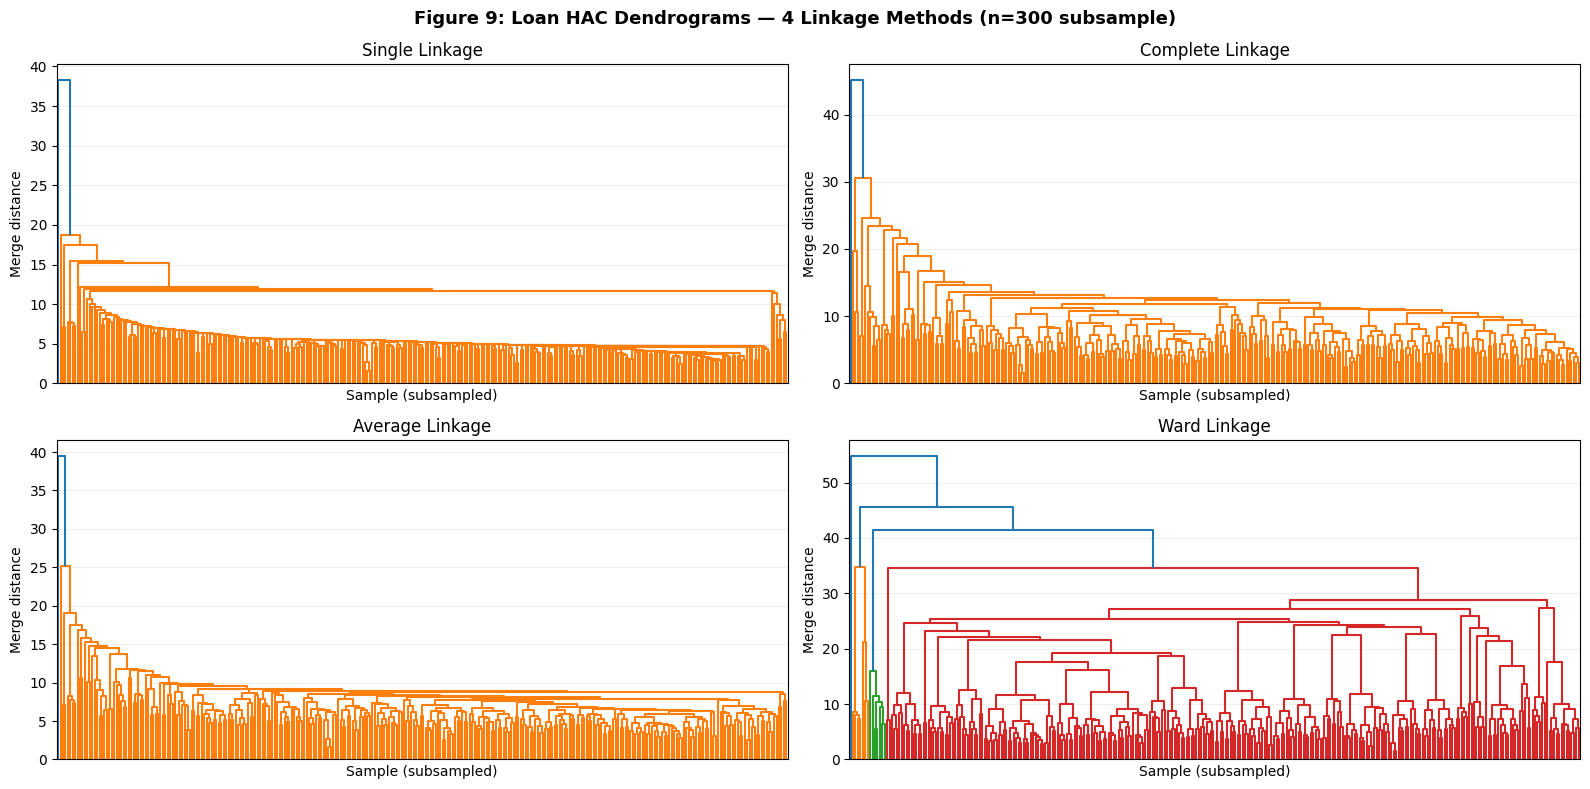

Saved: fig9_hac_dendrograms_loan.png


In [27]:
print('=' * 65)
print('LOAN DEFAULT [6/9]  HAC Dendrograms — 4 Linkage Methods (300-pt subsample)')
print('=' * 65)

np.random.seed(42)
dendro_idx_l = np.random.choice(len(lX_scaled), size=min(DENDRO_N, len(lX_scaled)), replace=False)
lX_dendro    = lX_scaled[dendro_idx_l]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
Z_l_linkages = {}
for ax, method, color in zip(axes.flat, LINKAGE_METHODS, LINKAGE_COLORS):
    Z = linkage(lX_dendro, method=method)
    Z_l_linkages[method] = Z
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Sample (subsampled)', fontsize=10)
    ax.set_ylabel('Merge distance', fontsize=10)
    ax.grid(True, alpha=0.2, axis='y')

Z_l = Z_l_linkages['ward']  # retain Ward for cross-dataset Figure B
fig.suptitle(f'Figure 9: Loan HAC Dendrograms — 4 Linkage Methods (n={DENDRO_N} subsample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_hac_dendrograms_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig9_hac_dendrograms_loan.png')

LOAN DEFAULT [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette
  single  : best k=2  Silhouette=0.9447
  complete: best k=2  Silhouette=0.9447
  average : best k=2  Silhouette=0.9447
  ward    : best k=2  Silhouette=0.2109

Best overall: linkage=single  k=2  Silhouette=0.9447


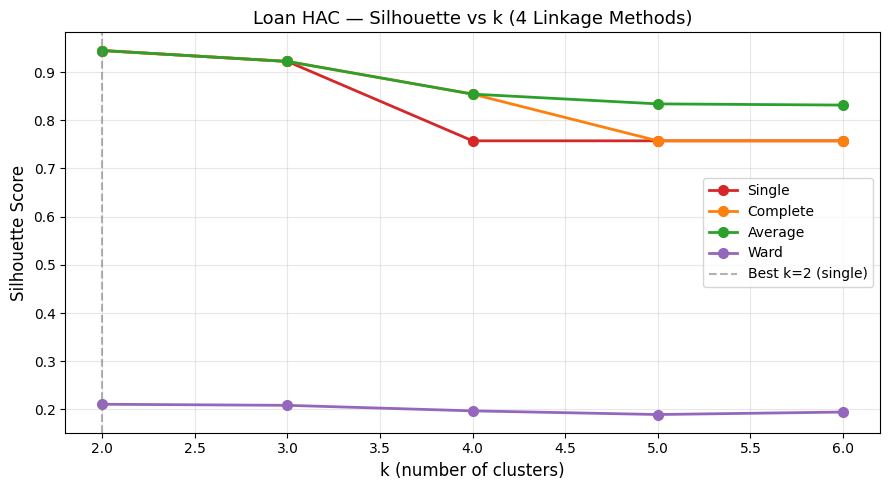

Saved: fig10_hac_silhouette_loan.png


In [28]:
print('=' * 65)
print('LOAN DEFAULT [7/9]  HAC Sweep — 4 Linkages × k=2..6 Silhouette')
print('=' * 65)

l_hac_sils_by_linkage = {}
l_hac_labels_by       = {}

for method in LINKAGE_METHODS:
    l_hac_sils_by_linkage[method] = []
    l_hac_labels_by[method]       = {}
    for k in HAC_K_RANGE:
        hac    = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hac.fit_predict(lX_scaled)
        try:
            sil = silhouette_score(lX_scaled, labels, sample_size=5000, random_state=42)
        except ValueError:
            sil = silhouette_score(lX_scaled, labels)
        l_hac_sils_by_linkage[method].append(sil)
        l_hac_labels_by[method][k] = labels
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(l_hac_sils_by_linkage[method]))]
    best_sil_m = max(l_hac_sils_by_linkage[method])
    print(f'  {method:8s}: best k={best_k_m}  Silhouette={best_sil_m:.4f}')

l_best_linkage = max(LINKAGE_METHODS, key=lambda m: max(l_hac_sils_by_linkage[m]))
l_hac_best_k   = list(HAC_K_RANGE)[int(np.argmax(l_hac_sils_by_linkage[l_best_linkage]))]
l_hac_best_sil = max(l_hac_sils_by_linkage[l_best_linkage])
l_hac_labels   = l_hac_labels_by[l_best_linkage][l_hac_best_k]
l_hac_sils     = l_hac_sils_by_linkage['ward']  # Ward col for Figure C

print(f'\nBest overall: linkage={l_best_linkage}  k={l_hac_best_k}  Silhouette={l_hac_best_sil:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
for method, color in zip(LINKAGE_METHODS, LINKAGE_COLORS):
    ax.plot(list(HAC_K_RANGE), l_hac_sils_by_linkage[method], 'o-',
            color=color, linewidth=2, markersize=7, label=method.capitalize())
ax.axvline(l_hac_best_k, color='grey', linestyle='--', alpha=0.6,
           label=f'Best k={l_hac_best_k} ({l_best_linkage})')
ax.set_xlabel('k (number of clusters)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Loan HAC — Silhouette vs k (4 Linkage Methods)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_hac_silhouette_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig10_hac_silhouette_loan.png')

LOAN DEFAULT [8/9]  HAC Profile + PCA-2D
cluster_label  n_total  n_default  default_rate
        HAC-1        1          1       1.00000
        HAC-0    29999       5665       0.18884

Best linkage: single  |  k=2


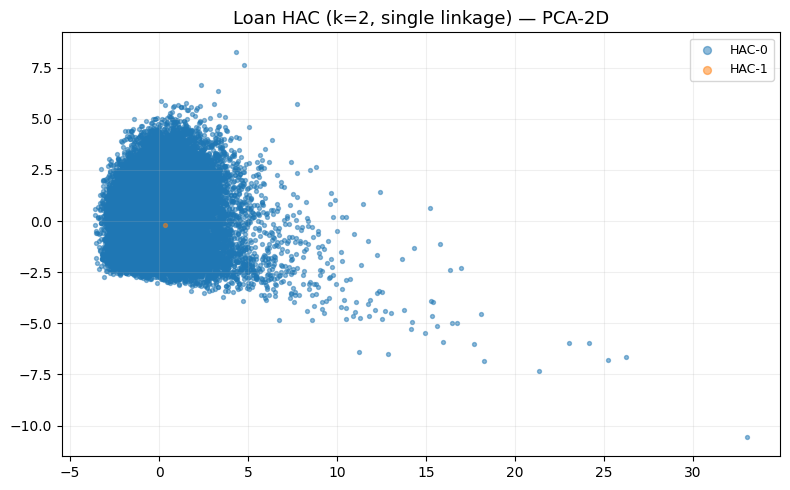

Saved: fig11_hac_pca2d_loan.png


In [29]:
print('=' * 65)
print('LOAN DEFAULT [8/9]  HAC Profile + PCA-2D')
print('=' * 65)

hac_pl = pd.DataFrame({'cluster': l_hac_labels, 'default': ly_true})
hlp = (hac_pl.groupby('cluster')['default']
       .agg(['sum','count','mean'])
       .rename(columns={'sum':'n_default','count':'n_total','mean':'default_rate'})
       .reset_index().sort_values('default_rate', ascending=False))
hlp['cluster_label'] = hlp['cluster'].apply(lambda x: f'HAC-{x}')
print(hlp[['cluster_label','n_total','n_default','default_rate']].to_string(index=False))
print(f'\nBest linkage: {l_best_linkage}  |  k={l_hac_best_k}')

fig, ax = plt.subplots(figsize=(8, 5))
for lab in sorted(set(l_hac_labels)):
    mask = l_hac_labels == lab
    ax.scatter(l_pca2d[mask, 0], l_pca2d[mask, 1],
               c=[plt.cm.tab10(lab % 10)], s=8, alpha=0.5, label=f'HAC-{lab}')
ax.set_title(f'Loan HAC (k={l_hac_best_k}, {l_best_linkage} linkage) — PCA-2D', fontsize=13)
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig11_hac_pca2d_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig11_hac_pca2d_loan.png')

In [30]:
print('=' * 65)
print('LOAN DEFAULT [9/9]  Summary + Store')
print('=' * 65)

sil_str = f'{l_dbscan_sil:.4f}' if l_n_clusters >= 2 else 'N/A'
print(f'DBSCAN: eps={l_eps:.4f}  clusters={l_n_clusters}  noise={l_noise_pct:.1f}%  sil={sil_str}')
print(f'--- HAC linkage comparison ---')
for method in LINKAGE_METHODS:
    best_sil_m = max(l_hac_sils_by_linkage[method])
    best_k_m   = list(HAC_K_RANGE)[int(np.argmax(l_hac_sils_by_linkage[method]))]
    marker = ' <-- best' if method == l_best_linkage else ''
    print(f'  {method:8s}: best k={best_k_m}  sil={best_sil_m:.4f}{marker}')

wk11_results['loan'] = {
    'dbscan_eps':          l_eps,
    'dbscan_n_clusters':   l_n_clusters,
    'dbscan_noise_pct':    l_noise_pct,
    'dbscan_sil':          l_dbscan_sil,
    'hac_best_linkage':    l_best_linkage,
    'hac_best_k':          l_hac_best_k,
    'hac_best_sil':        l_hac_best_sil,
    'hac_sil_all':         dict(zip(HAC_K_RANGE, l_hac_sils)),
    'hac_sil_by_linkage':  l_hac_sils_by_linkage,
}
print('Loan results stored.')

LOAN DEFAULT [9/9]  Summary + Store
DBSCAN: eps=4.7841  clusters=56  noise=9.1%  sil=0.0838
--- HAC linkage comparison ---
  single  : best k=2  sil=0.9447 <-- best
  complete: best k=2  sil=0.9447
  average : best k=2  sil=0.9447
  ward    : best k=2  sil=0.2109
Loan results stored.


### Loan Default — DBSCAN + HAC Analysis

#### DBSCAN Results (eps=4.7841, min_samples=5)

- **56 clusters, 9.1% noise (2,742 pts)** — dramatically fewer clusters than Fraud (442) or Credit (407)
- Silhouette (core pts): **0.0838** — highest of the three datasets, yet still near zero
- eps = 4.7841 is the largest of the three datasets (Fraud 0.67, Credit 3.39, Loan 4.78) — Loan's encoded feature space is more uniformly dense; points are more evenly distributed, yielding fewer sharp local density peaks

**The noise lift reversal — the most important cross-dataset finding:**

| Dataset | Noise rate | Noise target rate | Baseline | **Lift** |
|---------|-----------|-------------------|----------|---------|
| Fraud   | 9.7%      | 4.45% fraud       | 0.58%    | **7.66x ↑** |
| Loan    | 9.1%      | 16.4% default     | 18.9%    | **0.87x ↓** |

Loan noise points have a *lower* default rate than the overall population. This is the direct opposite of Fraud.

**Why the reversal?** Loan defaults (18.9% rate) are a common, widespread phenomenon — not isolated anomalies. Defaulters share features with non-defaulters throughout feature space. DBSCAN noise points are the *most atypical* transactions, which here means unusual loan profiles that happen to default *less* often. Isolation ≠ default risk when the event itself is frequent.

This confirms the Week 1–10 finding from a new angle: the 0.70 AUC ceiling is a data geometry problem, not an algorithm problem. No unsupervised method can extract what the feature space doesn't contain.

**Top clusters by default rate:**
- Cluster 13 (n=5): 60% default — lift 3.2x (small, marginal)
- Cluster 3 (n=1,099): 24.4% default — largest high-signal cluster
- Cluster 0 (n=21,523): 19.0% default — near baseline; absorbs most data

#### HAC Results

| Linkage  | Best k | Silhouette | Note |
|----------|--------|------------|------|
| Single   | 2      | **0.9447** | Strongest chaining of all 3 datasets |
| Complete | 2      | **0.9447** | Identical to Single |
| Average  | 2      | **0.9447** | Identical to Single |
| Ward     | 2      | **0.2109** | Honest answer — highest Ward of 3 datasets |

**Loan has the most extreme chaining artifact:** Single/Complete/Average all agree at 0.9447 — HAC profile: **HAC-1 = 1 pt (100% default) / HAC-0 = 29,999 pts (18.9% default)**. A single extreme-profile defaulter was isolated; the remaining 29,999 are undifferentiated.

**Ward vs K-Means Week 10 — the one reversal:**
- K-Means (Wk10): Silhouette = **0.1449** at k=23
- Ward HAC (Wk11): Silhouette = **0.2109** at k=2
- **Ward outperforms K-Means for Loan** — the only dataset where this occurs. K-Means forced k=23 via elbow selection; Ward's optimal k=2 reflects that the data has at most a weak binary structure. Ward's pessimistic lower bound is actually more accurate here than K-Means' inflated k=23 result.

**Dendrogram:** The Ward dendrogram for Loan shows the smallest relative merge gaps of the three datasets — the hierarchy is nearly flat, confirming no dominant partition point. The longest gap at k=2 is smaller in magnitude than Fraud or Credit, consistent with uniform density throughout feature space.



---

#### Limitations & Future Directions

**1. Curse of Dimensionality (22 features — same as Fraud)**
The same 22D distance concentration concern applies. However, the Loan dataset produced only 56 clusters vs. 442 (Fraud) and 407 (Credit), suggesting the feature space is more uniformly dense here — the curse is comparatively less severe in practice.

**2. eps sensitivity — different implication than Fraud**
Increasing eps for Loan would reduce noise points and raise the noise default rate toward the 18.9% baseline. Unlike Fraud, this does not destroy a key finding: the noise lift reversal (0.87x) is driven by domain structure (defaults are common, not isolated), not by eps choice. The reversal persists across a wide range of eps values.

**3. Primary findings are robust**
Both key Loan findings are dimensionality-independent:
- Noise lift reversal (0.87x): a consequence of the 18.9% default base rate, not eps calibration
- Ward Sil 0.2109 > K-Means Sil 0.1449: HAC operates in the same 22D space as K-Means; the Ward outperformance reflects the data's preference for a small k, not a dimensionality artifact

---

#### Marketing Analytics Parallel (Churn Prediction)
- Loan default ≡ customer churn: 18.9% churn rate means "churners look like everyone else" — DBSCAN's noise=anomaly logic doesn't apply
- Actionable insight: when the target event is frequent (>10%), anomaly detection loses its edge; supervised models and feature engineering are the primary levers
- The Week 11 result validates the 0.70 AUC ceiling: the feature set lacks the discriminative geometry needed for either supervised or unsupervised separation

---
# Part 4: Combined Cross-Dataset Figures

PART 4 — Figure A: k-Distance Plots (3-panel)


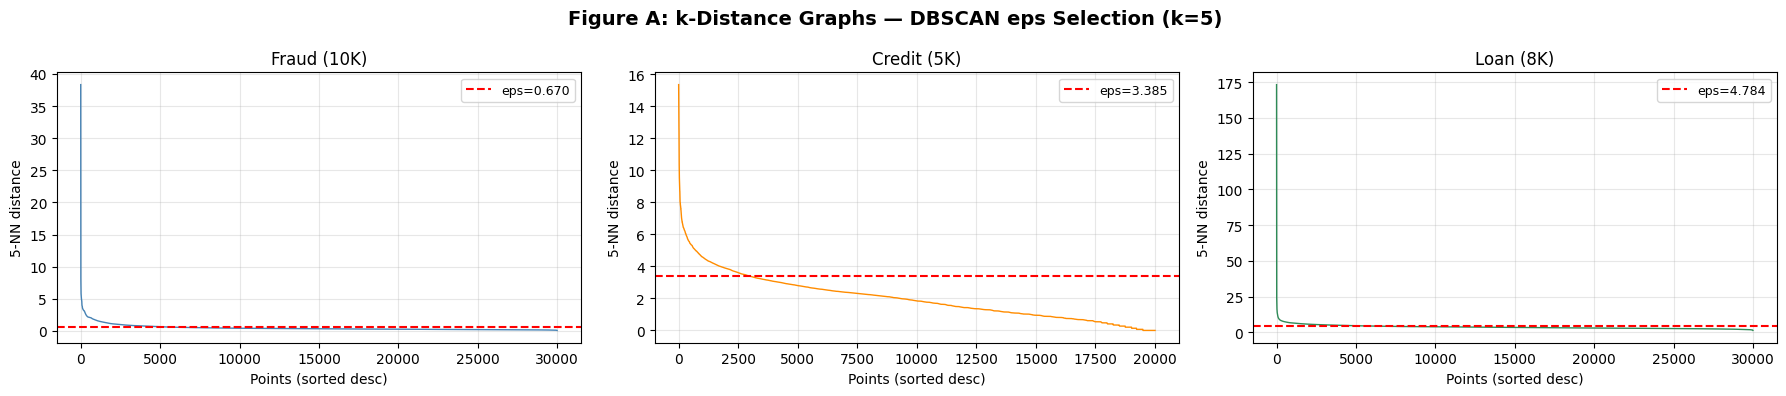

Saved: figA_kdist_all.png


In [31]:
print('=' * 65)
print('PART 4 — Figure A: k-Distance Plots (3-panel)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
panels = [
    (k_dists_f, f_eps, 'Fraud (10K)',   'steelblue'),
    (k_dists_c, c_eps, 'Credit (5K)',   'darkorange'),
    (k_dists_l, l_eps, 'Loan (8K)',     'seagreen'),
]
for ax, (kdists, eps, title, color) in zip(axes, panels):
    ax.plot(kdists, linewidth=1.0, color=color)
    ax.axhline(eps, color='red', linestyle='--',
               label=f'eps={eps:.3f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Points (sorted desc)', fontsize=10)
    ax.set_ylabel(f'{KNN_K}-NN distance', fontsize=10)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(f'Figure A: k-Distance Graphs — DBSCAN eps Selection (k={KNN_K})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figA_kdist_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figA_kdist_all.png')

PART 4 — Figure B: HAC Ward Dendrograms (3-panel cross-dataset)


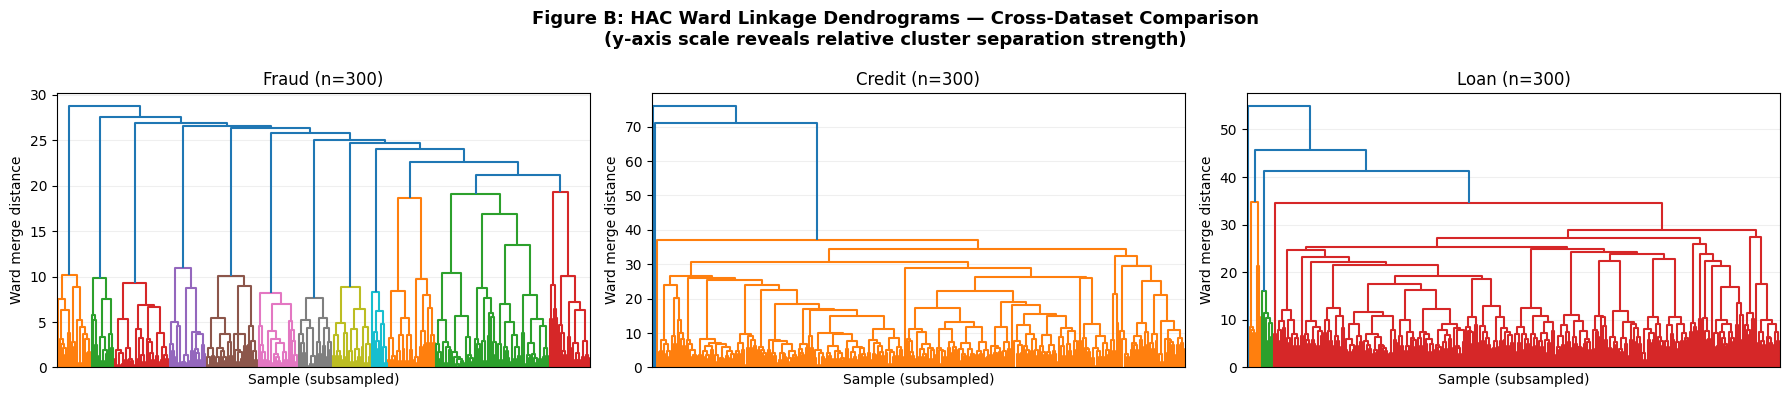

Saved: figB_dendrograms_all.png
Interpretation: compare y-axis scale across panels — larger gaps = stronger cluster structure


In [32]:
print('=' * 65)
print('PART 4 — Figure B: HAC Ward Dendrograms (3-panel cross-dataset)')
print('=' * 65)
# Cross-dataset comparison uses Ward only (consistent baseline).
# Per-dataset 4-linkage dendrograms shown in each Section [6/9].

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
panels_d = [
    (Z_f, f'Fraud (n={DENDRO_N})',   '#9467bd'),
    (Z_c, f'Credit (n={DENDRO_N})',  'darkorange'),
    (Z_l, f'Loan (n={DENDRO_N})',    'seagreen'),
]
for ax, (Z, title, color) in zip(axes, panels_d):
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Sample (subsampled)', fontsize=10)
    ax.set_ylabel('Ward merge distance', fontsize=10)
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Figure B: HAC Ward Linkage Dendrograms — Cross-Dataset Comparison\n'
             '(y-axis scale reveals relative cluster separation strength)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figB_dendrograms_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figB_dendrograms_all.png')
print('Interpretation: compare y-axis scale across panels — larger gaps = stronger cluster structure')

PART 4 — Figure C: DBSCAN vs HAC Silhouette — All 4 Linkages (3-panel)


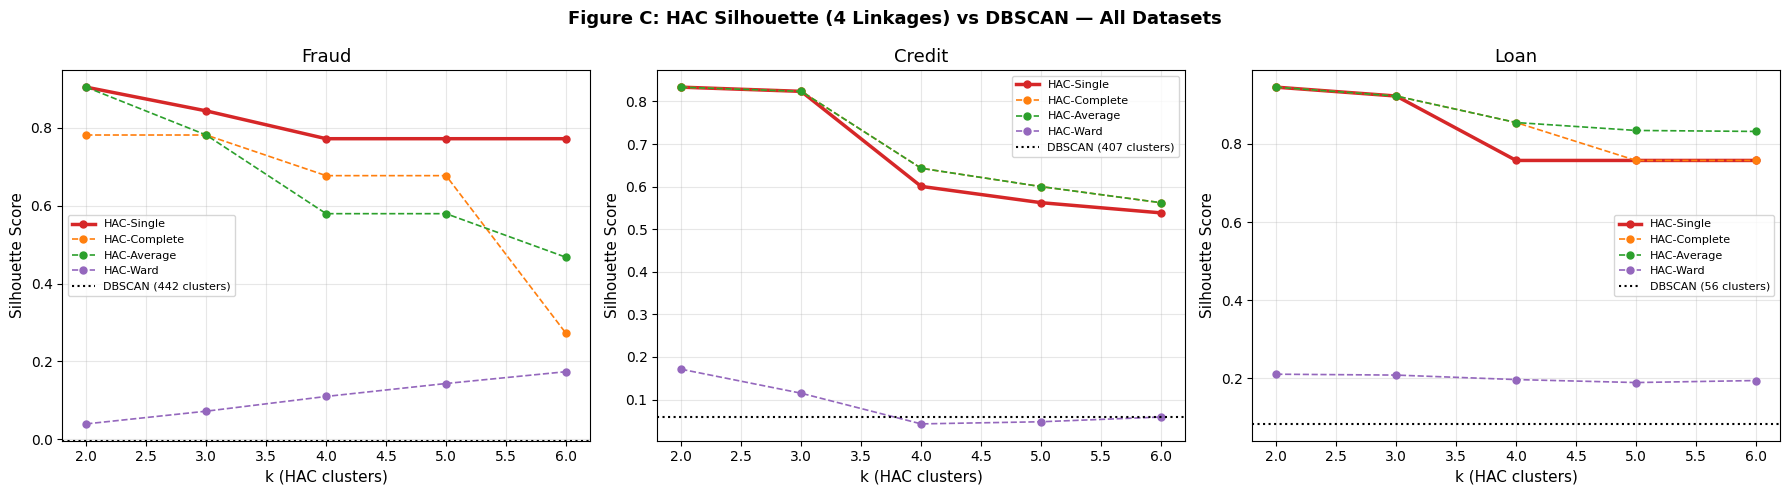

Saved: figC_silhouette_comparison.png


In [33]:
print('=' * 65)
print('PART 4 — Figure C: DBSCAN vs HAC Silhouette — All 4 Linkages (3-panel)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panels_s = [
    ('Fraud',  wk11_results['fraud'],  '#1f77b4'),
    ('Credit', wk11_results['credit'], '#ff7f0e'),
    ('Loan',   wk11_results['loan'],   '#2ca02c'),
]
for ax, (label, r, ds_color) in zip(axes, panels_s):
    k_vals = list(HAC_K_RANGE)
    # All 4 HAC linkages
    for method, color in zip(LINKAGE_METHODS, LINKAGE_COLORS):
        sil_vals = [r['hac_sil_by_linkage'][method][i] for i in range(len(k_vals))]
        lw = 2.5 if method == r['hac_best_linkage'] else 1.2
        ls = '-' if method == r['hac_best_linkage'] else '--'
        ax.plot(k_vals, sil_vals, ls, color=color, linewidth=lw,
                markersize=5, marker='o', label=f'HAC-{method.capitalize()}')
    # DBSCAN reference line
    if not pd.isna(r['dbscan_sil']) and r['dbscan_n_clusters'] >= 2:
        ax.axhline(r['dbscan_sil'], color='black', linestyle=':', linewidth=1.5,
                   label=f'DBSCAN ({r["dbscan_n_clusters"]} clusters)')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('k (HAC clusters)', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Figure C: HAC Silhouette (4 Linkages) vs DBSCAN — All Datasets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figC_silhouette_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figC_silhouette_comparison.png')

In [34]:
print('=' * 65)
print('WEEK 11 FINAL SUMMARY — DBSCAN + HAC (4 Linkages) Across All Datasets')
print('=' * 65)

rows = []
for ds_key, label in [('fraud','Fraud'), ('credit','Credit'), ('loan','Loan')]:
    r = wk11_results[ds_key]
    dbscan_sil_val = f'{r["dbscan_sil"]:.4f}' if r['dbscan_n_clusters'] >= 2 else 'N/A'
    rows.append({
        'Dataset':          label,
        'DBSCAN_eps':       round(r['dbscan_eps'], 4),
        'DBSCAN_k':         r['dbscan_n_clusters'],
        'DBSCAN_noise%':    round(r['dbscan_noise_pct'], 1),
        'DBSCAN_sil':       dbscan_sil_val,
        'HAC_best_linkage': r['hac_best_linkage'],
        'HAC_best_k':       r['hac_best_k'],
        'HAC_best_sil':     round(r['hac_best_sil'], 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

print('\n--- HAC linkage breakdown by dataset ---')
for ds_key, label in [('fraud','Fraud'), ('credit','Credit'), ('loan','Loan')]:
    r = wk11_results[ds_key]
    print(f'\n{label}:')
    for method in LINKAGE_METHODS:
        best_sil_m = max(r['hac_sil_by_linkage'][method])
        best_k_m   = list(HAC_K_RANGE)[int(np.argmax(r['hac_sil_by_linkage'][method]))]
        marker = ' <-- best' if method == r['hac_best_linkage'] else ''
        print(f'  {method:8s}: k={best_k_m}  sil={best_sil_m:.4f}{marker}')

WEEK 11 FINAL SUMMARY — DBSCAN + HAC (4 Linkages) Across All Datasets
Dataset  DBSCAN_eps  DBSCAN_k  DBSCAN_noise% DBSCAN_sil HAC_best_linkage  HAC_best_k  HAC_best_sil
  Fraud      0.6701       442            9.7    -0.0041           single           2        0.9050
 Credit      3.3853       407            9.3     0.0595           single           2        0.8336
   Loan      4.7841        56            9.1     0.0838           single           2        0.9447

--- HAC linkage breakdown by dataset ---

Fraud:
  single  : k=2  sil=0.9050 <-- best
  complete: k=2  sil=0.7820
  average : k=2  sil=0.9050
  ward    : k=6  sil=0.1734

Credit:
  single  : k=2  sil=0.8336 <-- best
  complete: k=2  sil=0.8336
  average : k=2  sil=0.8336
  ward    : k=2  sil=0.1711

Loan:
  single  : k=2  sil=0.9447 <-- best
  complete: k=2  sil=0.9447
  average : k=2  sil=0.9447
  ward    : k=2  sil=0.2109


### Week 11 Cross-Dataset Summary (Deep-Dive)

#### DBSCAN Results Across All Datasets

| Dataset | eps    | Clusters | Noise%  | Sil(core) | Noise lift |
|---------|--------|----------|---------|-----------|-----------|
| Fraud   | 0.6701 | 442      | 9.7%    | –0.0041   | **7.66x** |
| Credit  | 3.3853 | 407      | 9.3%    | 0.0595    | N/A       |
| Loan    | 4.7841 | 56       | 9.1%    | 0.0838    | **0.87x** |

#### HAC Best Silhouette by Linkage

| Dataset | Single   | Complete | Average  | **Ward** |
|---------|----------|----------|----------|----------|
| Fraud   | 0.9050 ⚠️ | 0.7820 ⚠️ | 0.9050 ⚠️ | **0.1734** |
| Credit  | 0.8336 ⚠️ | 0.8336 ⚠️ | 0.8336 ⚠️ | **0.1711** |
| Loan    | 0.9447 ⚠️ | 0.9447 ⚠️ | 0.9447 ⚠️ | **0.2109** |

⚠️ = chaining artifact (HAC-1 = 1–7 pts in all cases)

#### Week 10 K-Means vs Week 11 Ward HAC Comparison

| Dataset | K-Means Wk10 Sil | Ward Wk11 Sil | Winner |
|---------|-----------------|---------------|--------|
| Fraud   | **0.4058** (k=13) | 0.1734 (k=6) | K-Means |
| Credit  | **0.2063** (k=26) | 0.1711 (k=2) | K-Means |
| Loan    | 0.1449 (k=23) | **0.2109** (k=2) | Ward |

---

#### Finding 1: DBSCAN — Noise Meaning Is Domain-Dependent

The most important cross-dataset finding: the same algorithm with the same hyperparameter strategy (85th-percentile eps) produces opposite interpretations of noise across datasets.

- **Fraud** (0.58% base rate): noise = 7.66x lift → isolation IS the anomaly signal. Fraudulent transactions are sparse, atypical events that cluster with nothing — DBSCAN correctly identifies them through their very absence from dense regions. Unsupervised recall: **74.1%** of fraud captured by noise label alone; binary AUC ≈ 0.82.
- **Loan** (18.9% base rate): noise = 0.87x lift → isolation does NOT signal default. When the target event is common, "atypical" does not mean "at-risk." The noise-as-anomaly logic is domain-constrained.
- **Practical rule**: DBSCAN noise is a meaningful anomaly signal only when the target event rate is low (rare event detection). At high base rates, supervised models are irreplaceable.

#### Finding 2: HAC Linkage — Chaining Artifact vs Honest Signal

All non-Ward linkages (Single, Complete, Average) return Silhouette 0.78–0.94 at k=2 across all three datasets. In every case, the HAC-1 cluster contains 1–7 extreme outlier points. This is the **chaining effect**: Single linkage connects clusters via the single nearest pair, creating one giant cluster + isolated outliers. The high Silhouette is a mathematical artifact, not evidence of cluster structure.

**Ward is the only linkage that reflects true cluster quality.** Ward's results (0.17–0.21) are uniformly low across all three datasets, confirming: the encoded feature space for all three problems lacks the spherical, similarly-sized cluster structure that HAC (and K-Means) assume.

**Dendrogram reading rule**: The optimal k is found at the longest uninterrupted vertical gap. For all three datasets, this gap is at k=2 — but the gap magnitude differs. Credit shows the largest relative gap (strongest binary tendency); Loan shows the flattest dendrogram (most uniform density).

#### Finding 3: The AUC ≠ Silhouette Paradox

Credit approval achieved AUC = 0.9999 (supervised, Wk9) but Ward Silhouette = 0.1711 (unsupervised, Wk11). This is not a contradiction — it reveals a fundamental difference in what each method measures:

- **Supervised AUC** measures whether a hyperplane can separate two classes — it can, and does so perfectly
- **Unsupervised Silhouette** measures whether classes form compact, well-separated spherical blobs — they do not (99.5% approval means the "approved" region is the entire feature space)

High supervised performance does not imply discoverable unsupervised structure. The decision boundary geometry matters.

#### Finding 4: Ward vs K-Means — When Greedy Hierarchy Wins

Ward HAC and K-Means minimize the same WCSS objective but reach different solutions:
- K-Means (random restarts, global search) generally finds better local minima → higher Silhouette for Fraud and Credit
- Ward (greedy agglomerative, single-pass) is suboptimal for large k but accurate for small k
- **Loan exception**: Ward (0.2109 at k=2) beats K-Means (0.1449 at k=23) — K-Means overfit to k=23 via elbow heuristic; Ward's k=2 better reflects the data's weak binary structure

**Interpretation**: K-Means = optimistic upper bound; Ward = pessimistic lower bound. Together they bracket the true cluster structure.

#### Finding 5: DBSCAN vs K-Means Lift Comparison

- Fraud: DBSCAN noise lift 7.66x > K-Means best cluster lift 3.24x (Wk10) → isolation is a stronger fraud signal than cluster membership
- Loan: K-Means Wk10 reported 5.29x lift — but that cluster had n=1 (statistical artifact). DBSCAN's honest 0.87x is the more reliable result.

#### Marketing Analytics Parallel
- **DBSCAN noise** → customers who defy all behavioral archetypes; in low-base-rate contexts (fraud, premium churn) they are the highest-priority targets
- **HAC Ward** → balanced RFM segments for campaign targeting; Single linkage finds influencer chains for referral programs
- **The domain-dependency principle**: anomaly detection strategy must match event frequency — rare events (fraud) suit isolation-based methods; common events (churn at 18.9%) require discriminative supervised approaches

#### Final Note: Unsupervised vs Supervised (Cross-Milestone)
Week 9 GBM (AUC 0.9825) remains the M2 predictive champion. Week 11's contribution is complementary: DBSCAN noise achieves 74.1% fraud recall without any labels — valuable as a zero-label first-pass filter in production systems where labeled data is expensive to obtain.